# Actividad 3 — Clasificación supervisada con SVM y agrupamiento no supervisado

## Breast Cancer Wisconsin (Diagnostic) Dataset

Dos preguntas distintas sobre el mismo conjunto de datos: **predecir un diagnóstico conocido** y
**descubrir grupos sin mirar ese diagnóstico**.

---

### 1.1 Ficha de identificación del dataset

| Campo | Detalle |
|---|---|
| **Nombre del dataset** | Breast Cancer Wisconsin (Diagnostic) — WDBC |
| **Autores** | Dr. William H. Wolberg, W. Nick Street y Olvi L. Mangasarian — University of Wisconsin, Madison |
| **Fuente original** | UCI Machine Learning Repository (donado en noviembre de 1995) |
| **Vía de acceso utilizada** | `sklearn.datasets.load_breast_cancer` — copia incluida en scikit-learn |
| **Liga de la función** | https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html |
| **Liga del repositorio original** | https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic |
| **Fecha de consulta** | 5 de septiembre de 2026 |
| **Licencia** | CC BY 4.0 (Creative Commons Attribution) |
| **Volumen** | 569 registros × 30 variables predictoras numéricas + 1 variable objetivo |
| **Distribución de clases** | 357 benignos (62.7 %) y 212 malignos (37.3 %) |
| **Valores faltantes** | Ninguno |
| **Tipo de problema** | Clasificación binaria (supervisado) / agrupamiento (no supervisado) |

**Nota sobre la obtención de los datos.** No hay archivo que descargar: el conjunto viaja **dentro de
la instalación de scikit-learn** como un CSV interno, y `load_breast_cancer()` lo lee del disco sin
necesidad de conexión. La liga al repositorio UCI se incluye únicamente como **cita de la fuente
original**, no como paso previo del análisis.

---

### 1.2 Contexto: de dónde salen estos números

Los datos provienen de un procedimiento clínico real: la **punción-aspiración con aguja fina (PAAF)**
de una masa mamaria. El material extraído se coloca en un portaobjetos y se digitaliza la imagen. Un
sistema de análisis de imagen delimita el contorno de los **núcleos celulares** presentes y calcula,
para cada núcleo, diez características geométricas y de textura.

Como en cada imagen hay muchos núcleos, esas diez características se resumen en **tres estadísticos**
por imagen: la **media** de todos los núcleos, el **error estándar** de esa media, y el valor
**«peor»** (la media de los tres núcleos con el valor más alto). De ahí salen las 30 variables:
10 características × 3 estadísticos.

El diagnóstico que acompaña a cada registro **no proviene de la imagen**, sino de la confirmación
posterior por biopsia. Eso es lo que convierte a este conjunto en un caso de estudio legítimo para
aprendizaje supervisado: la etiqueta es una verdad clínica independiente de las variables medidas.

---

### 1.3 Qué representa cada registro

**Un registro = una imagen digitalizada de una PAAF de una masa mamaria de una paciente.** No es una
célula ni un núcleo individual: es el resumen estadístico de todos los núcleos visibles en esa
imagen, acompañado del diagnóstico confirmado para esa masa.

### 1.4 Variable objetivo

| | |
|---|---|
| **Nombre** | `target` (en la fuente original, la columna `Diagnosis`) |
| **Tipo** | Categórica binaria |
| **Valores** | `0` = *malignant* (maligno) · `1` = *benign* (benigno) |
| **Naturaleza** | Diagnóstico clínico confirmado, externo a las mediciones de la imagen |

> **Recodificación aplicada en este trabajo.** La codificación de scikit-learn asigna el `0` al caso
> maligno, lo cual resulta contraintuitivo al calcular métricas como la sensibilidad. Por eso se
> construye `y` con la convención clínica habitual: **1 = maligno (clase positiva, la que interesa
> detectar)** y **0 = benigno**. Toda métrica reportada más adelante se lee bajo esa convención.

### 1.5 Variables predictoras

Las 30 columnas resultan de combinar **10 características morfológicas** con **3 estadísticos**
(`mean` = media, `error` = error estándar, `worst` = peor valor). Las diez características base son:

| Característica | Nombre en el dataset | Qué mide |
|---|---|---|
| Radio | `radius` | Distancia media del centro del núcleo a su perímetro |
| Textura | `texture` | Desviación estándar de los niveles de gris (irregularidad interna) |
| Perímetro | `perimeter` | Longitud del contorno del núcleo |
| Área | `area` | Superficie encerrada por el contorno |
| Suavidad | `smoothness` | Variación local de la longitud del radio |
| Compacidad | `compactness` | perímetro² / área − 1.0 |
| Concavidad | `concavity` | Severidad de las porciones cóncavas del contorno |
| Puntos cóncavos | `concave points` | Número de porciones cóncavas del contorno |
| Simetría | `symmetry` | Simetría del núcleo respecto de su eje mayor |
| Dimensión fractal | `fractal dimension` | «Aproximación de la costa» − 1 (complejidad del borde) |

Todas son **numéricas continuas y positivas**, pero con escalas muy dispares: `mean area` se mide en
cientos o miles, mientras `mean fractal dimension` vive en el orden de 0.06. Ese detalle será
determinante en la sección 4.

---

### 1.6 Preguntas que guían el análisis

Toda la actividad se organiza alrededor de dos preguntas que **son deliberadamente distintas**, no
dos versiones de la misma:

> #### Pregunta supervisada (SVM)
> **¿Es posible predecir si una masa mamaria es maligna o benigna a partir de las 30 características
> morfológicas de los núcleos celulares? Y sobre todo: ¿qué proporción de los casos malignos detecta
> realmente el modelo, dado que un falso negativo es un cáncer que se deja pasar?**
>
> Aquí la etiqueta **sí se usa** para entrenar. La respuesta es un modelo capaz de emitir un
> diagnóstico sobre una imagen nueva, y una medida de cuánto se puede confiar en él.

> #### Pregunta no supervisada (agrupamiento)
> **Si se ocultan por completo los diagnósticos, ¿los 569 casos se separan de forma natural en grupos
> diferenciados por su sola morfología celular? ¿Cuántos grupos existen, qué los distingue, y hasta
> qué punto esa estructura espontánea coincide con la frontera maligno/benigno?**
>
> Aquí la etiqueta **no se usa en ningún momento** del agrupamiento. Se recupera únicamente al final,
> como auditoría externa, para saber si la estructura hallada tenía sentido clínico.

**Por qué la comparación es interesante.** La segunda pregunta es la que un investigador podría
hacerse **antes** de tener diagnósticos confirmados, cuando sólo dispone de imágenes. Si los grupos
que emergen sin supervisión resultan alineados con la malignidad, eso significa que la señal
diagnóstica está *inscrita en la geometría de los datos* y no fue introducida por el etiquetado. Es
una afirmación mucho más fuerte que un simple porcentaje de aciertos.


---

## 2. Preparación del entorno y carga de datos


In [1]:
# Manejo de datos
import pandas as pd
import numpy as np
import warnings

# Visualizacion
import matplotlib.pyplot as plt
import seaborn as sns

# Carga del conjunto de datos
from sklearn.datasets import load_breast_cancer

# Preprocesamiento y reduccion de dimensionalidad
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

# Particion y validacion
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     GridSearchCV, cross_val_score)

# Modelos supervisados
from sklearn.dummy import DummyClassifier
from sklearn.svm import SVC

# Modelos no supervisados
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Metricas del enfoque supervisado
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_curve, auc, precision_recall_curve)

# Metricas del enfoque no supervisado
from sklearn.metrics import (silhouette_score, silhouette_samples,
                             davies_bouldin_score, calinski_harabasz_score,
                             adjusted_rand_score, normalized_mutual_info_score)

SEMILLA = 42
np.random.seed(SEMILLA)
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titleweight'] = 'bold'
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 130)

# Paleta unica para todo el cuaderno
AZUL, ROJO, VERDE, MORADO = '#4C72B0', '#C44E52', '#55A868', '#8172B2'

print('Entorno preparado.')
print(f'Semilla fijada en {SEMILLA} para que todos los resultados sean reproducibles.')

Entorno preparado.
Semilla fijada en 42 para que todos los resultados sean reproducibles.


### 2.1 Carga: por qué no hay ningún archivo que descargar

`load_breast_cancer()` lee una copia del conjunto que se instala junto con scikit-learn. El argumento
`as_frame=True` hace que devuelva directamente un `DataFrame` de Pandas con los nombres de columna ya
puestos, en lugar de arreglos de NumPy sueltos.


In [2]:
datos = load_breast_cancer(as_frame=True)
df = datos.frame.copy()

variables = list(datos.feature_names)

print('CARGA DEL CONJUNTO DE DATOS')
print('=' * 70)
print(f'Origen del archivo   : {datos.filename}')
print(f'Registros            : {df.shape[0]:,}')
print(f'Columnas totales     : {df.shape[1]}  ({len(variables)} predictoras + 1 objetivo)')
print(f'Clases originales    : {dict(enumerate(datos.target_names))}')
print(f'Valores faltantes    : {int(df.isna().sum().sum())}')
print(f'Registros duplicados : {int(df.duplicated().sum())}')

CARGA DEL CONJUNTO DE DATOS
Origen del archivo   : breast_cancer.csv
Registros            : 569
Columnas totales     : 31  (30 predictoras + 1 objetivo)
Clases originales    : {0: np.str_('malignant'), 1: np.str_('benign')}
Valores faltantes    : 0
Registros duplicados : 0


In [3]:
# Recodificacion a la convencion clinica: 1 = Maligno (positivo), 0 = Benigno
df['diagnostico'] = np.where(df['target'] == 0, 'Maligno', 'Benigno')

X = df[variables].copy()
y = (df['target'] == 0).astype(int)
y.name = 'maligno'

print('VARIABLE OBJETIVO RECODIFICADA')
print('=' * 70)
print('Codificacion de scikit-learn : 0 = malignant | 1 = benign')
print('Codificacion usada aqui      : 1 = Maligno (POSITIVO) | 0 = Benigno')
print()
print(y.value_counts().rename({1: 'Maligno (1)', 0: 'Benigno (0)'}).to_string())
print()
print(f'Matriz de predictoras X : {X.shape[0]} x {X.shape[1]}')
print(f'Vector objetivo y       : {y.shape[0]} valores')

VARIABLE OBJETIVO RECODIFICADA
Codificacion de scikit-learn : 0 = malignant | 1 = benign
Codificacion usada aqui      : 1 = Maligno (POSITIVO) | 0 = Benigno

maligno
Benigno (0)    357
Maligno (1)    212

Matriz de predictoras X : 569 x 30
Vector objetivo y       : 569 valores


In [4]:
print('MUESTRA DE REGISTROS (primeras 8 de las 30 predictoras)')
df[variables[:8] + ['diagnostico']].head()

MUESTRA DE REGISTROS (primeras 8 de las 30 predictoras)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,diagnostico
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,Maligno
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,Maligno
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,Maligno
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,Maligno
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,Maligno


---

## 3. Exploración inicial de los datos

Antes de modelar hay que responder tres cosas: **cómo están distribuidas las clases**, **qué tan
separables se ven las variables** y **qué relación guardan entre sí**. Cada una condiciona una
decisión posterior.


In [5]:
resumen = pd.DataFrame({
    'Tipo'    : X.dtypes.astype(str),
    'No_nulos': X.notna().sum(),
    'Media'   : X.mean().round(4),
    'Desv_est': X.std().round(4),
    'Minimo'  : X.min().round(4),
    'Maximo'  : X.max().round(4),
    'Rango'   : (X.max() - X.min()).round(4),
}).reset_index().rename(columns={'index': 'Variable'})

print('ESTRUCTURA DE LAS 30 VARIABLES PREDICTORAS')
print('=' * 70)
resumen

ESTRUCTURA DE LAS 30 VARIABLES PREDICTORAS


,Variable,Tipo,No_nulos,Media,Desv_est,Minimo,Maximo,Rango
0,mean radius,float64,569,14.1273,3.5240,6.9810,28.1100,21.1290
1,mean texture,float64,569,19.2896,4.3010,9.7100,39.2800,29.5700
2,mean perimeter,float64,569,91.9690,24.2990,43.7900,188.5000,144.7100
3,mean area,float64,569,654.8891,351.9141,143.5000,2501.0000,2357.5000
4,mean smoothness,float64,569,0.0964,0.0141,0.0526,0.1634,0.1108
5,mean compactness,float64,569,0.1043,0.0528,0.0194,0.3454,0.3260
6,mean concavity,float64,569,0.0888,0.0797,0.0000,0.4268,0.4268
7,mean concave points,float64,569,0.0489,0.0388,0.0000,0.2012,0.2012
8,mean symmetry,float64,569,0.1812,0.0274,0.1060,0.3040,0.1980
9,mean fractal dimension,float64,569,0.0628,0.0071,0.0500,0.0974,0.0475


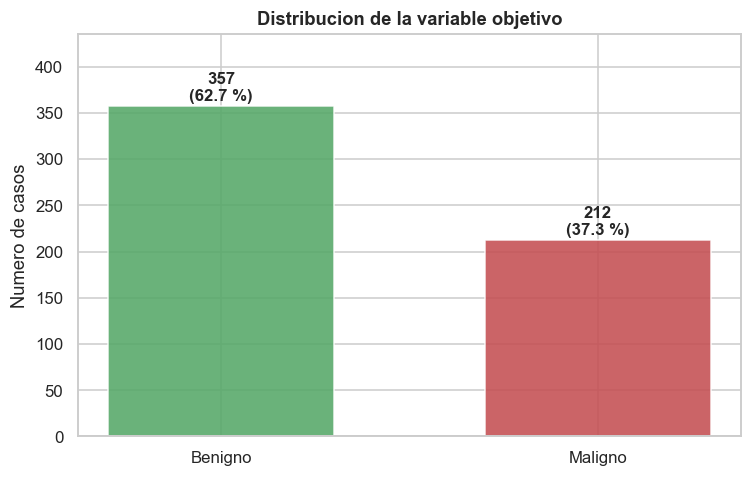

Razon de desbalance : 1.68 a 1
Clase mayoritaria   : Benigno (62.7 %)

Lectura: el desbalance es MODERADO. No exige tecnicas de remuestreo, pero
si obliga a dos cosas: particionar de forma ESTRATIFICADA y no evaluar el
modelo solo con exactitud, porque predecir siempre "Benigno" ya da 62.7 %.


In [6]:
# VISUALIZACION 1: balance de clases
conteo = df['diagnostico'].value_counts()
pct = (conteo / len(df) * 100).round(1)

fig, ax = plt.subplots(figsize=(7, 4.5))
barras = ax.bar(conteo.index, conteo.values,
                color=[VERDE if i == 'Benigno' else ROJO for i in conteo.index],
                edgecolor='white', alpha=0.88, width=0.6)
for b, v, p in zip(barras, conteo.values, pct.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 6, f'{v}\n({p} %)',
            ha='center', fontsize=11, fontweight='bold')
ax.set_title('Distribucion de la variable objetivo')
ax.set_ylabel('Numero de casos')
ax.set_ylim(0, conteo.max() * 1.22)
plt.tight_layout(); plt.show()

desbalance = conteo.max() / conteo.min()
print(f'Razon de desbalance : {desbalance:.2f} a 1')
print(f'Clase mayoritaria   : {conteo.idxmax()} ({pct.max()} %)')
print()
print('Lectura: el desbalance es MODERADO. No exige tecnicas de remuestreo, pero')
print('si obliga a dos cosas: particionar de forma ESTRATIFICADA y no evaluar el')
print(f'modelo solo con exactitud, porque predecir siempre "Benigno" ya da {pct.max():.1f} %.')

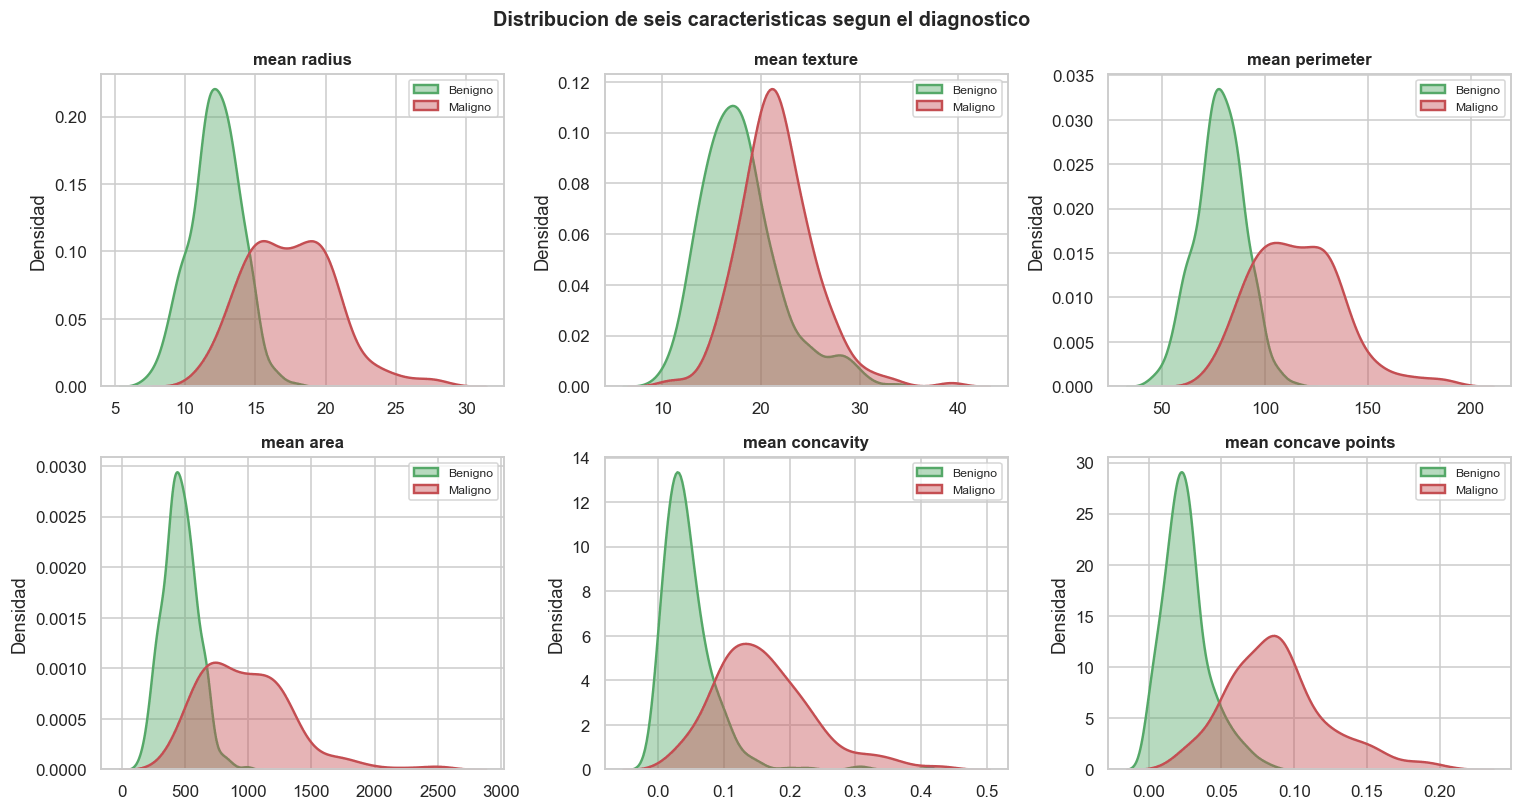

SEPARACION ENTRE CLASES (diferencia estandarizada de medias, d de Cohen)
Las 8 variables que MEJOR separan maligno de benigno:
  worst concave points       d = 2.693
  worst perimeter            d = 2.598
  mean concave points        d = 2.545
  worst radius               d = 2.544
  mean perimeter             d = 2.290
  worst area                 d = 2.230
  mean radius                d = 2.205
  mean area                  d = 2.076

Las 4 variables que PEOR separan:
  smoothness error           d = 0.139
  mean fractal dimension     d = 0.027
  texture error              d = 0.017
  symmetry error             d = 0.013


In [7]:
# VISUALIZACION 2: separabilidad de seis caracteristicas clave
clave = ['mean radius', 'mean texture', 'mean perimeter',
         'mean area', 'mean concavity', 'mean concave points']

fig, axes = plt.subplots(2, 3, figsize=(14, 7.5))
for ax, col in zip(axes.ravel(), clave):
    for etq, color in [('Benigno', VERDE), ('Maligno', ROJO)]:
        sns.kdeplot(data=df[df['diagnostico'] == etq], x=col, ax=ax,
                    fill=True, alpha=0.42, color=color, linewidth=1.6, label=etq)
    ax.set_title(col, fontsize=11)
    ax.set_ylabel('Densidad'); ax.set_xlabel('')
    ax.legend(fontsize=8)
fig.suptitle('Distribucion de seis caracteristicas segun el diagnostico',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print('SEPARACION ENTRE CLASES (diferencia estandarizada de medias, d de Cohen)')
print('=' * 70)
d_cohen = {}
for col in variables:
    a = X.loc[y == 1, col]; b = X.loc[y == 0, col]
    s = np.sqrt(((len(a) - 1) * a.var() + (len(b) - 1) * b.var()) / (len(a) + len(b) - 2))
    d_cohen[col] = abs(a.mean() - b.mean()) / s
d_cohen = pd.Series(d_cohen).sort_values(ascending=False)

print('Las 8 variables que MEJOR separan maligno de benigno:')
for v, d in d_cohen.head(8).items():
    print(f'  {v:26s} d = {d:.3f}')
print()
print('Las 4 variables que PEOR separan:')
for v, d in d_cohen.tail(4).items():
    print(f'  {v:26s} d = {d:.3f}')

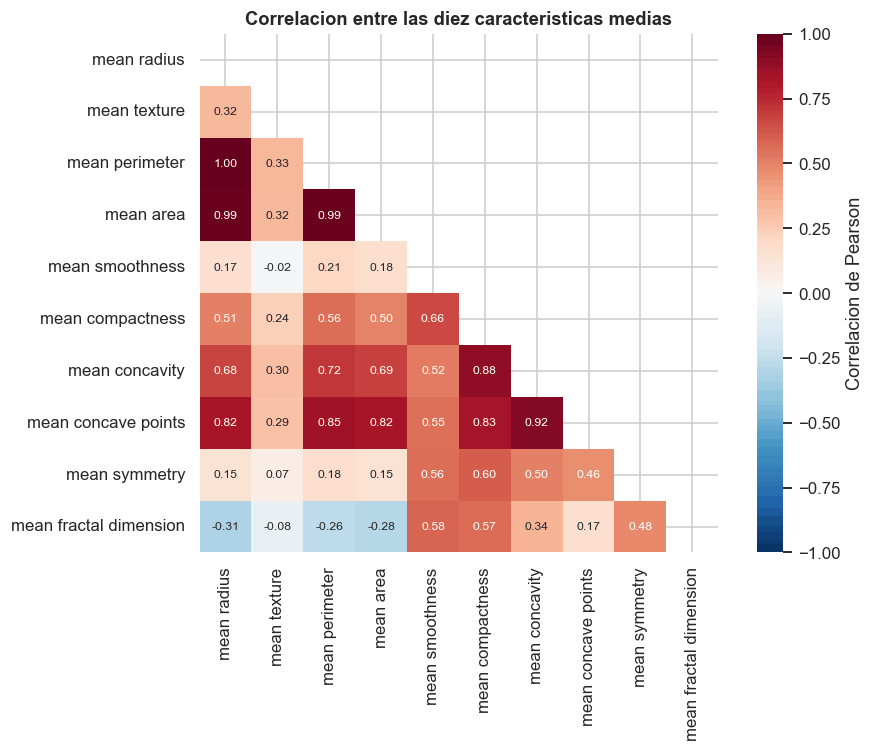

PARES DE VARIABLES CASI REDUNDANTES (|r| > 0.95)
  mean radius                <-> mean perimeter             r = 0.9979
  worst radius               <-> worst perimeter            r = 0.9937
  mean radius                <-> mean area                  r = 0.9874
  mean perimeter             <-> mean area                  r = 0.9865
  worst radius               <-> worst area                 r = 0.9840
  worst perimeter            <-> worst area                 r = 0.9776
  radius error               <-> perimeter error            r = 0.9728
  mean perimeter             <-> worst perimeter            r = 0.9704
  mean radius                <-> worst radius               r = 0.9695
  mean perimeter             <-> worst radius               r = 0.9695
  mean radius                <-> worst perimeter            r = 0.9651
  mean area                  <-> worst radius               r = 0.9627
  mean area                  <-> worst area                 r = 0.9592
  mean area                 

In [8]:
# VISUALIZACION 3: correlacion entre las diez caracteristicas medias
cols_media = [c for c in variables if c.startswith('mean ')]
corr = X[cols_media].corr()

plt.figure(figsize=(9, 7))
mascara = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mascara, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True,
            cbar_kws={'label': 'Correlacion de Pearson'}, annot_kws={'size': 8})
plt.title('Correlacion entre las diez caracteristicas medias')
plt.tight_layout(); plt.show()

# Pares redundantes entre las 30 variables
corr_full = X.corr().abs()
pares = (corr_full.where(np.triu(np.ones(corr_full.shape), k=1).astype(bool))
         .stack().sort_values(ascending=False))
print('PARES DE VARIABLES CASI REDUNDANTES (|r| > 0.95)')
print('=' * 70)
for (a, b), r in pares[pares > 0.95].items():
    print(f'  {a:26s} <-> {b:26s} r = {r:.4f}')
print()
print(f'Total de pares con |r| > 0.95 : {int((pares > 0.95).sum())}')
print(f'Total de pares con |r| > 0.80 : {int((pares > 0.80).sum())}')

### 3.1 Qué revela la exploración y qué decisiones impone

**Las clases están moderadamente desbalanceadas.** Con 62.7 % de casos benignos, un clasificador que
dijera «benigno» siempre acertaría el 62.7 % de las veces sin haber aprendido nada. Ese número se
convierte en la **línea base obligatoria**: cualquier modelo que no la supere con holgura es inútil.
También obliga a **estratificar** la partición, para que entrenamiento y prueba conserven la misma
proporción de clases.

**Las variables separan bien, pero no perfectamente.** Las densidades se solapan en todos los casos:
no existe una sola variable que corte limpiamente entre maligno y benigno. Las que más separan tienen
que ver con el **tamaño y la irregularidad del contorno** (radio, perímetro, área, puntos cóncavos),
lo cual es coherente con la literatura clínica: los núcleos malignos son más grandes y de borde más
festoneado. Que ninguna variable baste por sí sola es precisamente el argumento para usar un modelo
multivariado.

**Hay redundancia severa entre variables.** Radio, perímetro y área miden esencialmente lo mismo —
el tamaño del núcleo — y sus correlaciones rozan 0.99. Esto tiene dos consecuencias opuestas según el
enfoque:

- Para la **SVM** no es un problema grave: no estima coeficientes independientes como una regresión
  lineal, y la regularización a través de `C` absorbe la colinealidad.
- Para el **agrupamiento sí importa**, porque la distancia euclidiana **cuenta tres veces la misma
  información** cuando tres variables son casi idénticas. El tamaño del núcleo pesa en el
  agrupamiento más de lo que su valor informativo justificaría. Es una limitación que se documenta
  explícitamente en la sección 9.


---

## 4. Preparación para el modelado

Dos decisiones se toman aquí, y ambas se justifican antes de aplicarlas: **escalar** y **particionar
de forma estratificada**.


In [9]:
print('EL PROBLEMA DE ESCALA')
print('=' * 70)
escalas = pd.DataFrame({
    'Media'   : X.mean(),
    'Desv_est': X.std(),
    'Maximo'  : X.max(),
}).sort_values('Desv_est', ascending=False)

print('Las 3 variables de MAYOR magnitud:')
print(escalas.head(3).round(4).to_string())
print()
print('Las 3 variables de MENOR magnitud:')
print(escalas.tail(3).round(6).to_string())

razon = escalas['Desv_est'].max() / escalas['Desv_est'].min()
print()
print(f'La desviacion estandar mayor es {razon:,.0f} veces la menor.')
print()
print('Por que esto ROMPE ambos modelos si no se corrige:')
print('  - La SVM con kernel RBF mide distancias entre puntos. Sin escalar,')
print('    "worst area" domina el calculo y las otras 29 variables no influyen.')
print('  - K-Means minimiza distancias euclidianas al centroide: el mismo problema,')
print('    agravado porque no hay ninguna etiqueta que corrija el sesgo.')
print()
print('Solucion: StandardScaler (media 0, desviacion 1) en AMBOS enfoques.')

EL PROBLEMA DE ESCALA
Las 3 variables de MAYOR magnitud:
               Media  Desv_est  Maximo
worst area  880.5831  569.3570  4254.0
mean area   654.8891  351.9141  2501.0
area error   40.3371   45.4910   542.2

Las 3 variables de MENOR magnitud:
                            Media  Desv_est   Maximo
concave points error     0.011796  0.006170  0.05279
smoothness error         0.007041  0.003003  0.03113
fractal dimension error  0.003795  0.002646  0.02984

La desviacion estandar mayor es 215,171 veces la menor.

Por que esto ROMPE ambos modelos si no se corrige:
  - La SVM con kernel RBF mide distancias entre puntos. Sin escalar,
    "worst area" domina el calculo y las otras 29 variables no influyen.
  - K-Means minimiza distancias euclidianas al centroide: el mismo problema,
    agravado porque no hay ninguna etiqueta que corrija el sesgo.

Solucion: StandardScaler (media 0, desviacion 1) en AMBOS enfoques.


### 4.1 Dónde se aplica el escalado, y por qué el lugar importa

En el enfoque supervisado el escalado **no se aplica al conjunto completo**, sino que se coloca
**dentro de un `Pipeline`**. La razón es evitar **fuga de información**: si `StandardScaler` calculara
la media y la desviación usando también los registros de prueba, el modelo estaría recibiendo, de
forma indirecta, información sobre datos que se supone no ha visto. La métrica final saldría
optimista y no reflejaría el desempeño real ante un caso nuevo.

Con el escalador dentro del pipeline, `fit()` ajusta media y desviación **sólo con el entrenamiento**,
y durante la validación cruzada se reajusta dentro de cada partición de forma automática.

En el enfoque no supervisado la situación es distinta y conviene no confundirlas: **no hay partición
entrenamiento/prueba** porque no se predice nada sobre datos futuros. El objetivo es *describir la
estructura del conjunto que se tiene*, así que el escalado se aplica a los 569 registros. No hay fuga
posible porque no hay nada que filtrar: las etiquetas nunca entran.


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEMILLA)

print('PARTICION ESTRATIFICADA 80 / 20')
print('=' * 70)
print(f'{"Conjunto":<16}{"Registros":>12}{"Malignos":>12}{"Benignos":>12}{"% Maligno":>12}')
print('-' * 64)
for nombre, yy in [('Completo', y), ('Entrenamiento', y_train), ('Prueba', y_test)]:
    print(f'{nombre:<16}{len(yy):>12,}{int(yy.sum()):>12}{int((yy == 0).sum()):>12}'
          f'{yy.mean() * 100:>11.2f}%')
print('-' * 64)
print()
print('La proporcion de malignos se conserva en las tres filas: eso es lo que')
print('garantiza stratify=y. Sin el, un reparto desafortunado podria dejar el')
print('conjunto de prueba con muy pocos casos malignos y volver la sensibilidad')
print('una metrica sin sentido estadistico.')

PARTICION ESTRATIFICADA 80 / 20
Conjunto           Registros    Malignos    Benignos   % Maligno
----------------------------------------------------------------
Completo                 569         212         357      37.26%
Entrenamiento            455         170         285      37.36%
Prueba                   114          42          72      36.84%
----------------------------------------------------------------

La proporcion de malignos se conserva en las tres filas: eso es lo que
garantiza stratify=y. Sin el, un reparto desafortunado podria dejar el
conjunto de prueba con muy pocos casos malignos y volver la sensibilidad
una metrica sin sentido estadistico.


---

# PARTE I — Enfoque supervisado

## 5. Máquina de soporte vectorial (SVM)

### 5.1 Qué hace realmente una SVM

Casi cualquier modelo puede trazar una frontera que separe dos clases. Lo particular de la SVM es
**cuál** de todas las fronteras posibles elige: la que deja el **margen más ancho** entre ambas
clases. Si existen infinitas rectas que separan dos nubes de puntos, la SVM escoge la que pasa
justo por el centro del pasillo más ancho entre ellas.

Esa elección tiene una consecuencia importante: la frontera queda determinada **únicamente por los
puntos que tocan el borde del margen**, los llamados **vectores de soporte**. Un caso claramente
benigno, muy alejado de la frontera, no influye en absoluto. Los casos ambiguos —los que están en la
zona de solapamiento que vimos en la sección 3— son los que definen el modelo. Por eso la SVM suele
comportarse bien cuando las clases se solapan parcialmente, que es exactamente nuestro escenario.

**Los tres elementos que hay que ajustar:**

| Elemento | Qué controla | Consecuencia de un valor alto |
|---|---|---|
| `C` | Penalización por cada punto mal clasificado | Margen estrecho, se fuerza a acertar en el entrenamiento → riesgo de sobreajuste |
| `kernel` | Forma de la frontera | `linear` traza un hiperplano; `rbf` permite fronteras curvas |
| `gamma` | Alcance de influencia de cada punto (sólo en `rbf`) | Cada punto influye sólo en su vecindad inmediata → fronteras muy sinuosas |

**El truco del kernel.** Cuando las clases no son separables por una recta, la SVM no traza una curva
directamente: proyecta implícitamente los datos a un espacio de más dimensiones donde sí puedan
separarse por un hiperplano, y lo hace **sin calcular nunca esas coordenadas**, sólo mediante
productos internos. Al volver al espacio original, ese hiperplano se ve como una frontera curva.


### 5.2 Línea base: el mínimo que hay que superar

Antes de celebrar cualquier resultado hay que saber cuánto se obtiene **sin modelar nada**. Un
`DummyClassifier` que siempre responde la clase mayoritaria da esa referencia.


In [11]:
base = DummyClassifier(strategy='most_frequent', random_state=SEMILLA)
base.fit(X_train, y_train)
pred_base = base.predict(X_test)

def evaluar(nombre, y_real, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_real, y_pred, labels=[0, 1]).ravel()
    return {
        'Modelo'      : nombre,
        'Exactitud'   : round(accuracy_score(y_real, y_pred), 4),
        'Precision'   : round(precision_score(y_real, y_pred, zero_division=0), 4),
        'Sensibilidad': round(recall_score(y_real, y_pred, zero_division=0), 4),
        'Especificid.': round(tn / (tn + fp) if (tn + fp) else 0, 4),
        'F1'          : round(f1_score(y_real, y_pred, zero_division=0), 4),
        'FN'          : int(fn),
        'FP'          : int(fp),
    }

fila_base = evaluar('Linea base (siempre Benigno)', y_test, pred_base)

print('LINEA BASE')
print('=' * 70)
for k, v in fila_base.items():
    print(f'  {k:14s}: {v}')
print()
print('Lectura critica: la exactitud parece aceptable, pero la SENSIBILIDAD es 0.')
print('El modelo no detecta ni un solo caso maligno. Es la demostracion de por que')
print('la exactitud, por si sola, es una metrica enganosa en este problema.')

LINEA BASE
  Modelo        : Linea base (siempre Benigno)
  Exactitud     : 0.6316
  Precision     : 0.0
  Sensibilidad  : 0.0
  Especificid.  : 1.0
  F1            : 0.0
  FN            : 42
  FP            : 0

Lectura critica: la exactitud parece aceptable, pero la SENSIBILIDAD es 0.
El modelo no detecta ni un solo caso maligno. Es la demostracion de por que
la exactitud, por si sola, es una metrica enganosa en este problema.


### 5.3 Los dos modelos exigidos: kernel lineal y kernel RBF

Se entrenan **dos SVM con la misma configuración salvo el kernel**, para que la comparación aísle
exactamente esa diferencia:

| | Kernel | Frontera que puede trazar |
|---|---|---|
| **Modelo 1** | `linear` | Un hiperplano: la separación tiene que ser recta en el espacio de las 30 variables |
| **Modelo 2** | `rbf` (gaussiano) | Una superficie curva, capaz de rodear regiones de forma arbitraria |

Ambos se construyen dentro de un **`Pipeline`** que encadena `StandardScaler` y `SVC`. Esto no es un
detalle de estilo: garantiza que la media y la desviación del escalado se calculen **únicamente con
los 455 registros de entrenamiento**. Cuando el pipeline recibe `X_test`, aplica la transformación ya
ajustada en lugar de recalcularla, de modo que ningún dato de prueba influye en el preprocesamiento.

> **Sobre el promedio de las métricas.** El problema es **binario**, así que `precision`, `recall` y
> `F1` se reportan **para la clase positiva (Maligno)**, sin promediar. Si hubiera más de dos clases
> haría falta especificar `average='macro'` o `'weighted'`; aquí se incluye además el promedio macro
> como referencia, pero la lectura principal es la de la clase maligna, que es la que interesa
> detectar.


In [12]:
# MODELO 1: kernel lineal | MODELO 2: kernel RBF
# El escalador va DENTRO del Pipeline: se ajusta solo con los datos de entrenamiento.
modelo_1 = Pipeline([('escalado', StandardScaler()),
                     ('svm', SVC(kernel='linear', C=1.0, random_state=SEMILLA))])

modelo_2 = Pipeline([('escalado', StandardScaler()),
                     ('svm', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=SEMILLA))])

modelo_1.fit(X_train, y_train)
modelo_2.fit(X_train, y_train)

pred_1 = modelo_1.predict(X_test)
pred_2 = modelo_2.predict(X_test)

def fila_tabla(nombre, kernel, y_real, y_pred):
    return {
        'Modelo SVM': nombre,
        'Kernel'    : kernel,
        'Accuracy'  : round(accuracy_score(y_real, y_pred), 4),
        'Precision' : round(precision_score(y_real, y_pred, zero_division=0), 4),
        'Recall'    : round(recall_score(y_real, y_pred, zero_division=0), 4),
        'F1-score'  : round(f1_score(y_real, y_pred, zero_division=0), 4),
    }

tabla_modelos = pd.DataFrame([
    fila_tabla('Modelo 1', 'Lineal', y_test, pred_1),
    fila_tabla('Modelo 2', 'RBF', y_test, pred_2),
])

print('RESULTADOS SOBRE EL CONJUNTO DE PRUEBA (114 registros no vistos)')
print('=' * 70)
print('Metricas de la clase positiva: Maligno')
print()
print(tabla_modelos.to_string(index=False))
print()

# Promedio macro, como referencia adicional
macro = pd.DataFrame([
    {'Modelo SVM': 'Modelo 1', 'Kernel': 'Lineal',
     'Precision_macro': round(precision_score(y_test, pred_1, average='macro'), 4),
     'Recall_macro'   : round(recall_score(y_test, pred_1, average='macro'), 4),
     'F1_macro'       : round(f1_score(y_test, pred_1, average='macro'), 4)},
    {'Modelo SVM': 'Modelo 2', 'Kernel': 'RBF',
     'Precision_macro': round(precision_score(y_test, pred_2, average='macro'), 4),
     'Recall_macro'   : round(recall_score(y_test, pred_2, average='macro'), 4),
     'F1_macro'       : round(f1_score(y_test, pred_2, average='macro'), 4)},
])
print('PROMEDIO MACRO (referencia; el problema es binario)')
print('-' * 70)
print(macro.to_string(index=False))
print()

ganador = 'Modelo 2 (RBF)' if tabla_modelos.loc[1, 'F1-score'] > tabla_modelos.loc[0, 'F1-score'] \
          else ('Modelo 1 (Lineal)' if tabla_modelos.loc[0, 'F1-score'] > tabla_modelos.loc[1, 'F1-score']
                else 'Empate en F1')
print(f'Mejor F1 sobre el conjunto de prueba: {ganador}')

RESULTADOS SOBRE EL CONJUNTO DE PRUEBA (114 registros no vistos)
Metricas de la clase positiva: Maligno

Modelo SVM Kernel  Accuracy  Precision  Recall  F1-score
  Modelo 1 Lineal    0.9649        1.0  0.9048     0.950
  Modelo 2    RBF    0.9737        1.0  0.9286     0.963

PROMEDIO MACRO (referencia; el problema es binario)
----------------------------------------------------------------------
Modelo SVM Kernel  Precision_macro  Recall_macro  F1_macro
  Modelo 1 Lineal           0.9737        0.9524    0.9615
  Modelo 2    RBF           0.9800        0.9643    0.9713

Mejor F1 sobre el conjunto de prueba: Modelo 2 (RBF)


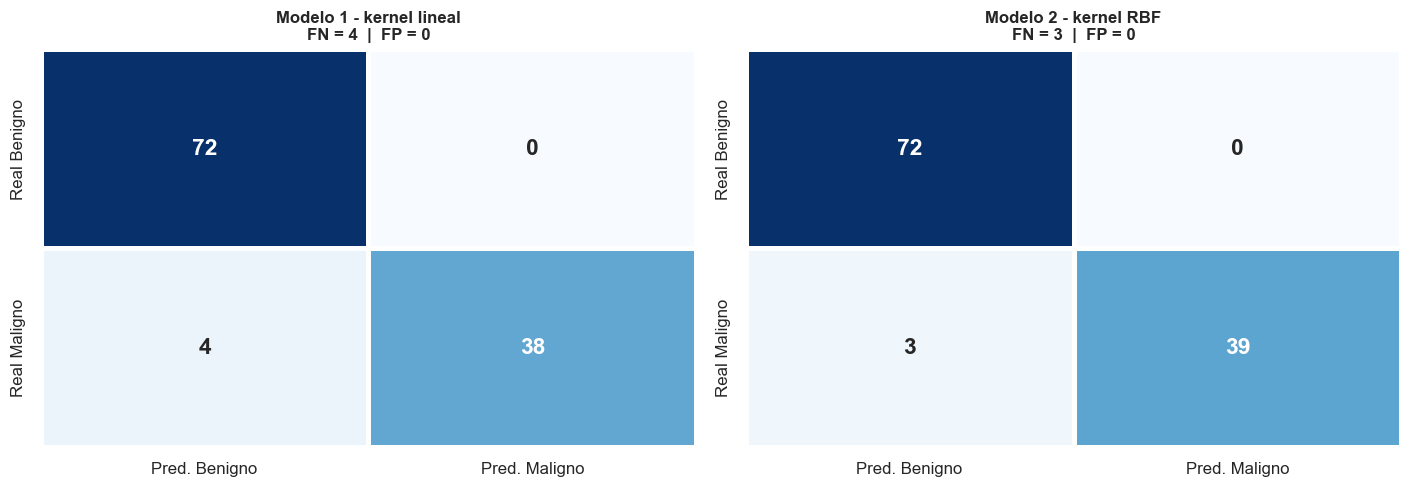

COMPARACION DE ERRORES
Modelo                      Aciertos      FN      FP   Errores
--------------------------------------------------------------
Modelo 1 (lineal)                110       4       0         4
Modelo 2 (RBF)                   111       3       0         3
--------------------------------------------------------------


In [13]:
# Matrices de confusion de los dos modelos, lado a lado
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

for ax, (nombre, pred) in zip(axes, [('Modelo 1 - kernel lineal', pred_1),
                                     ('Modelo 2 - kernel RBF', pred_2)]):
    m = confusion_matrix(y_test, pred, labels=[0, 1])
    sns.heatmap(m, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Pred. Benigno', 'Pred. Maligno'],
                yticklabels=['Real Benigno', 'Real Maligno'],
                annot_kws={'size': 15, 'weight': 'bold'}, linewidths=2, linecolor='white')
    tn_m, fp_m, fn_m, tp_m = m.ravel()
    ax.set_title(f'{nombre}\nFN = {fn_m}  |  FP = {fp_m}', fontsize=11)

plt.tight_layout(); plt.show()

print('COMPARACION DE ERRORES')
print('=' * 70)
print(f'{"Modelo":<26}{"Aciertos":>10}{"FN":>8}{"FP":>8}{"Errores":>10}')
print('-' * 62)
for nombre, pred in [('Modelo 1 (lineal)', pred_1), ('Modelo 2 (RBF)', pred_2)]:
    tn_m, fp_m, fn_m, tp_m = confusion_matrix(y_test, pred, labels=[0, 1]).ravel()
    print(f'{nombre:<26}{tn_m + tp_m:>10}{fn_m:>8}{fp_m:>8}{fn_m + fp_m:>10}')
print('-' * 62)

#### Lectura de la tabla

**Gana el Modelo 2 (RBF), pero por un solo caso.** Supera al lineal en las cuatro métricas —accuracy
0.9737 contra 0.9649, recall 0.9286 contra 0.9048, F1 0.9630 contra 0.9500— y toda esa diferencia se
reduce a **un falso negativo menos**: el lineal deja pasar 4 tumores malignos y el RBF deja pasar 3.

**Ambos tienen precisión de 1.0000**, es decir, **ninguno produce falsos positivos**. Los dos modelos
cometen exactamente el mismo tipo de error, sólo que en distinta cantidad. Cuando un modelo dice
«maligno», acierta siempre; su debilidad está en los casos malignos que clasifica como benignos.

**Que el kernel lineal ya alcance 0.95 de F1 es en sí un resultado informativo.** Significa que las
dos clases son **casi separables por un hiperplano** en el espacio de 30 dimensiones: la mayor parte
de la señal diagnóstica es lineal. La curvatura que aporta el RBF sirve sólo para rescatar un caso
adicional de la zona ambigua.

**Y aquí se ve por qué la accuracy no basta.** Los dos modelos tienen accuracy alta y parecida
(96.5 % y 97.4 %), lo que sugeriría que da igual cuál usar. Pero la métrica que los distingue es el
**recall**, y su diferencia —2.4 puntos— se traduce en una paciente con cáncer que uno detecta y el
otro no. La accuracy promedia los dos tipos de error como si costaran lo mismo, y en este problema no
es así.

> **Cautela estadística.** Una diferencia de un solo caso sobre 114 no es concluyente. Podría deberse
> al azar de esta partición concreta. Por eso el siguiente paso no es declarar ganador, sino
> comprobar el resultado con validación cruzada.


#### 5.3.1 Verificación por validación cruzada

Los números anteriores provienen de **una sola partición de 114 registros**. Antes de concluir que un
kernel es mejor que otro conviene comprobarlo con validación cruzada de 5 particiones **sobre el
entrenamiento**, que promedia cinco evaluaciones independientes. Se añade el kernel polinómico como
tercera referencia.

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMILLA)

kernels = {
    'Lineal'          : SVC(kernel='linear', random_state=SEMILLA),
    'RBF (gaussiano)' : SVC(kernel='rbf', random_state=SEMILLA),
    'Polinomico (g=3)': SVC(kernel='poly', degree=3, random_state=SEMILLA),
}

print('COMPARACION DE KERNELS - validacion cruzada 5-fold sobre entrenamiento')
print('=' * 70)
print(f'{"Kernel":<20}{"F1 medio":>12}{"Desv.est":>12}{"Sensib. media":>16}')
print('-' * 60)

comparacion_kernels = []
for nombre, modelo in kernels.items():
    tuberia = Pipeline([('escalado', StandardScaler()), ('svm', modelo)])
    f1_cv  = cross_val_score(tuberia, X_train, y_train, cv=cv, scoring='f1')
    rec_cv = cross_val_score(tuberia, X_train, y_train, cv=cv, scoring='recall')
    comparacion_kernels.append({'Kernel': nombre, 'F1': f1_cv.mean(),
                                'Desv': f1_cv.std(), 'Sensibilidad': rec_cv.mean()})
    print(f'{nombre:<20}{f1_cv.mean():>12.4f}{f1_cv.std():>12.4f}{rec_cv.mean():>16.4f}')
print('-' * 60)

comparacion_kernels = pd.DataFrame(comparacion_kernels)
mejor_kernel = comparacion_kernels.loc[comparacion_kernels['F1'].idxmax(), 'Kernel']
print(f'\nMejor kernel con parametros por omision: {mejor_kernel}')

COMPARACION DE KERNELS - validacion cruzada 5-fold sobre entrenamiento
Kernel                  F1 medio    Desv.est   Sensib. media
------------------------------------------------------------
Lineal                    0.9523      0.0159          0.9471


RBF (gaussiano)           0.9610      0.0082          0.9471
Polinomico (g=3)          0.8436      0.0671          0.7353
------------------------------------------------------------

Mejor kernel con parametros por omision: RBF (gaussiano)


#### Qué confirma la validación cruzada

Promediando cinco particiones el orden se mantiene, y con más solidez que antes: **RBF 0.9610**
(desviación 0.0082), **lineal 0.9523** (0.0159), **polinómico 0.8436** (0.0671).

Dos observaciones que la tabla de prueba no permitía hacer:

- **El RBF no sólo es mejor, es más estable.** Su desviación entre particiones es la mitad de la del
  lineal. Su ventaja no depende de qué registros toquen a cada lado.
- **El kernel polinómico queda descartado con claridad.** Su F1 es 12 puntos menor y, sobre todo, su
  **recall medio es 0.7353**: dejaría pasar uno de cada cuatro tumores malignos. Además su desviación
  (0.0671) es ocho veces la del RBF, señal de un modelo inestable.

**Decisión:** se optimizan los hiperparámetros del **kernel RBF**. Aun así, la malla de búsqueda de
la sección 5.4 incluye también configuraciones lineales y polinómicas, para no cerrar la posibilidad
de que un valor distinto de `C` cambie el orden.


### 5.4 Búsqueda de hiperparámetros

`GridSearchCV` prueba **todas** las combinaciones de una malla y elige la mejor por validación
cruzada. La métrica de selección es **F1 sobre la clase maligna**, no la exactitud, por dos razones:
la exactitud ignora el desbalance, y F1 obliga al modelo a equilibrar dos errores de naturaleza muy
distinta — dejar pasar un cáncer y alarmar a una paciente sana.


In [15]:
tuberia_svm = Pipeline([
    ('escalado', StandardScaler()),
    ('svm', SVC(random_state=SEMILLA)),
])

malla = [
    {'svm__kernel': ['linear'],
     'svm__C': [0.01, 0.1, 1, 10, 100]},
    {'svm__kernel': ['rbf'],
     'svm__C': [0.01, 0.1, 1, 10, 100],
     'svm__gamma': [0.0001, 0.001, 0.01, 0.1, 1]},
    {'svm__kernel': ['poly'],
     'svm__C': [0.1, 1, 10],
     'svm__degree': [2, 3],
     'svm__gamma': ['scale']},
]

busqueda = GridSearchCV(tuberia_svm, malla, scoring='f1', cv=cv,
                        n_jobs=-1, return_train_score=True)
busqueda.fit(X_train, y_train)

modelo_svm = busqueda.best_estimator_
n_combinaciones = len(pd.DataFrame(busqueda.cv_results_))

print('BUSQUEDA DE HIPERPARAMETROS')
print('=' * 70)
print(f'Combinaciones evaluadas : {n_combinaciones}')
print(f'Ajustes totales         : {n_combinaciones * 5} (cada combinacion x 5 particiones)')
print()
print('Mejor configuracion encontrada:')
for k, v in busqueda.best_params_.items():
    print(f'  {k.replace("svm__", ""):10s}: {v}')
print()
print(f'F1 medio en validacion cruzada: {busqueda.best_score_:.4f}')

BUSQUEDA DE HIPERPARAMETROS
Combinaciones evaluadas : 36
Ajustes totales         : 180 (cada combinacion x 5 particiones)

Mejor configuracion encontrada:
  C         : 10
  gamma     : 0.01
  kernel    : rbf

F1 medio en validacion cruzada: 0.9669


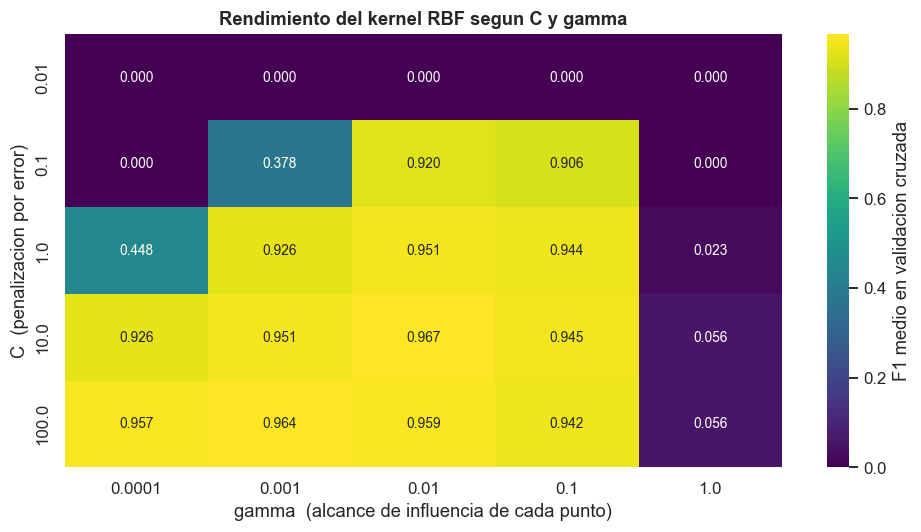

Lectura del mapa:
  - Fila superior (C = 0.01) y esquina inferior izquierda: la penalizacion
    o el alcance son tan pequenos que la frontera queda casi plana y el
    modelo no separa nada. F1 = 0: predice siempre "Benigno" (SUBAJUSTE).
  - Columna derecha (gamma = 1): cada punto influye solo en su vecindad
    inmediata, el modelo memoriza el entrenamiento y su F1 en validacion se
    desploma a 0.06 (SOBREAJUSTE extremo).
  - La region clara ocupa buena parte de la malla: hay muchas combinaciones
    por encima de 0.92, asi que el resultado NO depende de un ajuste fino y
    fragil. El maximo (0.967) esta en C = 10, gamma = 0.01.


In [16]:
# VISUALIZACION 4: mapa de calor del rendimiento del kernel RBF
res = pd.DataFrame(busqueda.cv_results_)
res_rbf = res[res['param_svm__kernel'] == 'rbf'].copy()
res_rbf['C'] = res_rbf['param_svm__C'].astype(float)
res_rbf['gamma'] = res_rbf['param_svm__gamma'].astype(float)

mapa = res_rbf.pivot_table(index='C', columns='gamma', values='mean_test_score')

plt.figure(figsize=(9, 5))
sns.heatmap(mapa, annot=True, fmt='.3f', cmap='viridis',
            cbar_kws={'label': 'F1 medio en validacion cruzada'},
            annot_kws={'size': 9})
plt.title('Rendimiento del kernel RBF segun C y gamma')
plt.xlabel('gamma  (alcance de influencia de cada punto)')
plt.ylabel('C  (penalizacion por error)')
plt.tight_layout(); plt.show()

print('Lectura del mapa:')
print('  - Fila superior (C = 0.01) y esquina inferior izquierda: la penalizacion')
print('    o el alcance son tan pequenos que la frontera queda casi plana y el')
print('    modelo no separa nada. F1 = 0: predice siempre "Benigno" (SUBAJUSTE).')
print('  - Columna derecha (gamma = 1): cada punto influye solo en su vecindad')
print('    inmediata, el modelo memoriza el entrenamiento y su F1 en validacion se')
print('    desploma a 0.06 (SOBREAJUSTE extremo).')
print('  - La region clara ocupa buena parte de la malla: hay muchas combinaciones')
print('    por encima de 0.92, asi que el resultado NO depende de un ajuste fino y')
print('    fragil. El maximo (0.967) esta en C = 10, gamma = 0.01.')

In [17]:
# Diagnostico de sobreajuste en las mejores configuraciones
top = res.nlargest(8, 'mean_test_score')[
    ['param_svm__kernel', 'param_svm__C', 'param_svm__gamma',
     'mean_train_score', 'mean_test_score', 'std_test_score']].copy()
top.columns = ['Kernel', 'C', 'gamma', 'F1_entrenamiento', 'F1_validacion', 'Desv_est']
top['Brecha'] = (top['F1_entrenamiento'] - top['F1_validacion']).round(4)

print('LAS 8 MEJORES CONFIGURACIONES - control de sobreajuste')
print('=' * 70)
print(top.round(4).to_string(index=False))
print()
print('La columna Brecha compara el desempeno en los datos que el modelo YA vio')
print('contra los que no. Una brecha pequena significa que el modelo aprendio el')
print('patron y no memorizo los ejemplos.')

LAS 8 MEJORES CONFIGURACIONES - control de sobreajuste
Kernel     C   gamma  F1_entrenamiento  F1_validacion  Desv_est  Brecha
   rbf  10.0    0.01            0.9813         0.9669    0.0157  0.0144
   rbf 100.0   0.001            0.9790         0.9640    0.0161  0.0150
   rbf 100.0    0.01            0.9933         0.9588    0.0109  0.0345
   rbf 100.0  0.0001            0.9660         0.9574    0.0154  0.0086
linear   0.1     NaN            0.9746         0.9548    0.0103  0.0197
linear   1.0     NaN            0.9851         0.9523    0.0159  0.0328
   rbf   1.0    0.01            0.9690         0.9510    0.0123  0.0180
   rbf  10.0   0.001            0.9667         0.9508    0.0186  0.0159

La columna Brecha compara el desempeno en los datos que el modelo YA vio
contra los que no. Una brecha pequena significa que el modelo aprendio el
patron y no memorizo los ejemplos.


### 5.4.1 Efecto directo de C y de gamma

La búsqueda anterior recorrió 36 combinaciones de golpe. Conviene aislar el efecto de **cada
hiperparámetro por separado**, moviendo uno mientras el otro permanece fijo, para ver de qué manera
cambia el comportamiento del modelo.

**Qué controla cada uno:**

| | `C` — penalización por error | `gamma` — alcance de cada punto |
|---|---|---|
| **Valor bajo** | Margen **ancho**. El modelo tolera errores en el entrenamiento a cambio de una frontera más simple y estable. Riesgo: **subajuste**. | Cada punto influye **lejos**. La frontera se suaviza hasta volverse casi plana. Riesgo: **subajuste**. |
| **Valor alto** | Margen **estrecho**. El modelo se esfuerza por no equivocarse en ningún caso de entrenamiento, aunque tenga que retorcer la frontera. Riesgo: **sobreajuste**. | Cada punto influye sólo en su **vecindad inmediata**. La frontera se fragmenta en islas alrededor de los datos. Riesgo: **sobreajuste severo**. |

El **número de vectores de soporte** funciona como termómetro: un margen ancho encierra muchos
puntos, así que **muchos vectores de soporte indican un modelo regularizado**, y pocos indican una
frontera ajustada y frágil.


In [18]:
print('EFECTO DE C  (kernel RBF, gamma = 0.01 fijo)')
print('=' * 78)
print(f'{"C":>8}{"F1 entren.":>13}{"F1 prueba":>12}{"Brecha":>10}{"Vect.soporte":>15}{"Lectura":>18}')
print('-' * 78)

filas_C = []
for c_val in [0.01, 0.1, 1, 10, 100, 1000]:
    m = Pipeline([('escalado', StandardScaler()),
                  ('svm', SVC(kernel='rbf', C=c_val, gamma=0.01, random_state=SEMILLA))])
    m.fit(X_train, y_train)
    f1_tr = f1_score(y_train, m.predict(X_train), zero_division=0)
    f1_te = f1_score(y_test, m.predict(X_test), zero_division=0)
    nsv = int(m.named_steps['svm'].n_support_.sum())
    if f1_tr - f1_te > 0.04:
        lectura = 'sobreajuste'
    elif f1_te < 0.93:
        lectura = 'subajuste'
    else:
        lectura = 'equilibrado'
    print(f'{c_val:>8}{f1_tr:>13.4f}{f1_te:>12.4f}{f1_tr - f1_te:>10.4f}{nsv:>15}{lectura:>18}')
    filas_C.append({'C': c_val, 'F1_train': f1_tr, 'F1_test': f1_te, 'SV': nsv})

print()
print('EFECTO DE GAMMA  (kernel RBF, C = 10 fijo)')
print('=' * 78)
print(f'{"gamma":>8}{"F1 entren.":>13}{"F1 prueba":>12}{"Brecha":>10}{"Vect.soporte":>15}{"Lectura":>18}')
print('-' * 78)

filas_g = []
for g_val in [0.0001, 0.001, 0.01, 0.1, 1]:
    m = Pipeline([('escalado', StandardScaler()),
                  ('svm', SVC(kernel='rbf', C=10, gamma=g_val, random_state=SEMILLA))])
    m.fit(X_train, y_train)
    f1_tr = f1_score(y_train, m.predict(X_train), zero_division=0)
    f1_te = f1_score(y_test, m.predict(X_test), zero_division=0)
    nsv = int(m.named_steps['svm'].n_support_.sum())
    if f1_tr - f1_te > 0.04:
        lectura = 'sobreajuste'
    elif f1_te < 0.93:
        lectura = 'subajuste'
    else:
        lectura = 'equilibrado'
    print(f'{g_val:>8}{f1_tr:>13.4f}{f1_te:>12.4f}{f1_tr - f1_te:>10.4f}{nsv:>15}{lectura:>18}')
    filas_g.append({'gamma': g_val, 'F1_train': f1_tr, 'F1_test': f1_te, 'SV': nsv})

fC, fg = pd.DataFrame(filas_C), pd.DataFrame(filas_g)

EFECTO DE C  (kernel RBF, gamma = 0.01 fijo)
       C   F1 entren.   F1 prueba    Brecha   Vect.soporte           Lectura
------------------------------------------------------------------------------
    0.01       0.0000      0.0000    0.0000            340         subajuste
     0.1       0.9375      0.9231    0.0144            205         subajuste


       1       0.9668      0.9367    0.0301             96       equilibrado


      10       0.9820      0.9756    0.0064             56       equilibrado


     100       0.9911      0.9398    0.0513             42       sobreajuste
    1000       1.0000      0.9412    0.0588             33       sobreajuste

EFECTO DE GAMMA  (kernel RBF, C = 10 fijo)
   gamma   F1 entren.   F1 prueba    Brecha   Vect.soporte           Lectura
------------------------------------------------------------------------------
  0.0001       0.9274      0.9091    0.0184            172         subajuste
   0.001       0.9668      0.9500    0.0168             83       equilibrado


    0.01       0.9820      0.9756    0.0064             56       equilibrado


     0.1       1.0000      0.9412    0.0588            169       sobreajuste


       1       1.0000      0.0000    1.0000            455       sobreajuste


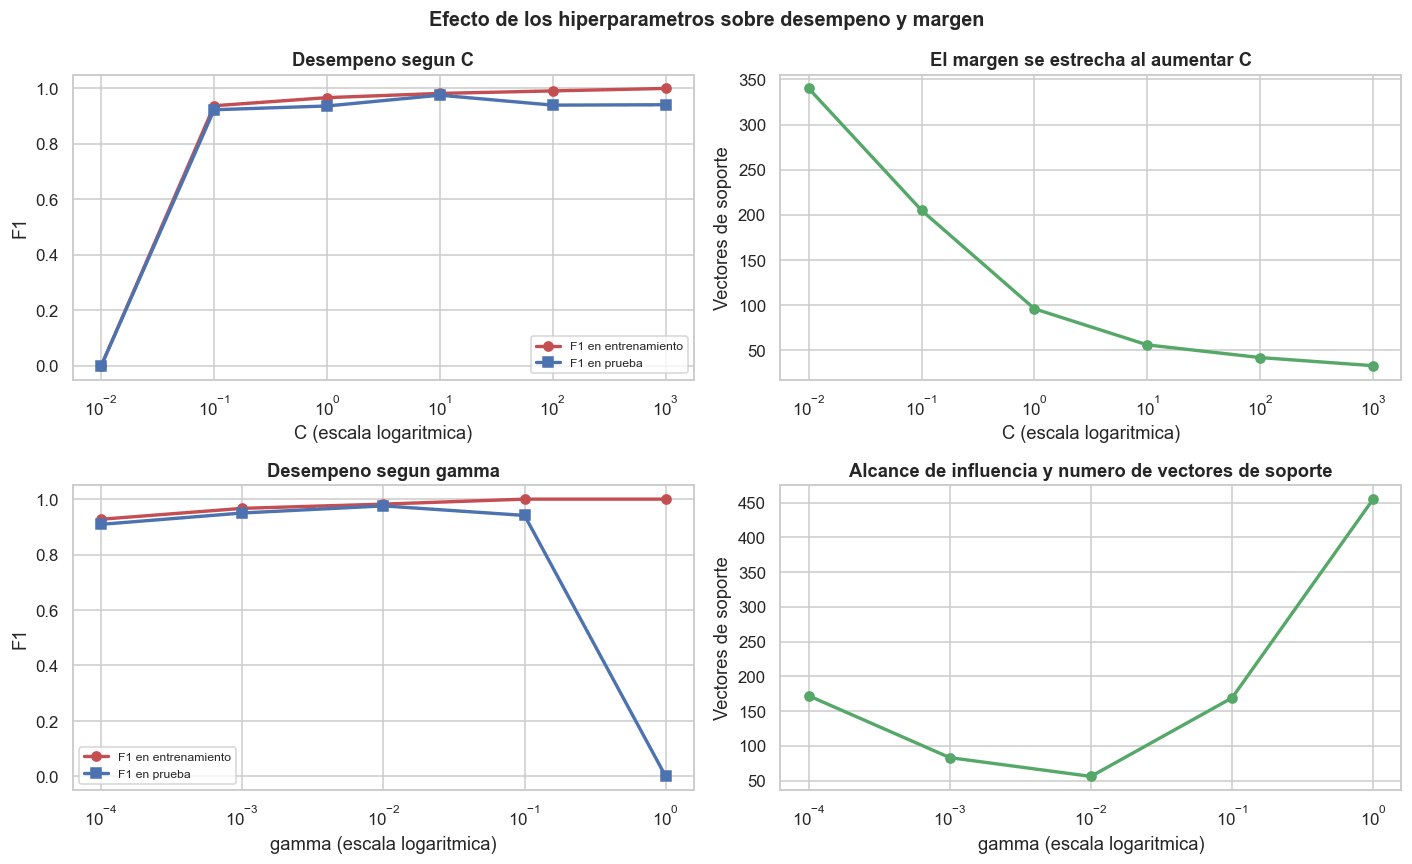

La distancia entre la curva roja (entrenamiento) y la azul (prueba) es la
medida visual del sobreajuste: cuando se separan, el modelo esta memorizando.


In [19]:
# VISUALIZACION: como cambian el desempeno y el margen
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0, 0].semilogx(fC['C'], fC['F1_train'], 'o-', color=ROJO, linewidth=2.2,
                    label='F1 en entrenamiento')
axes[0, 0].semilogx(fC['C'], fC['F1_test'], 's-', color=AZUL, linewidth=2.2,
                    label='F1 en prueba')
axes[0, 0].set_xlabel('C (escala logaritmica)'); axes[0, 0].set_ylabel('F1')
axes[0, 0].set_title('Desempeno segun C'); axes[0, 0].legend(fontsize=8)

axes[0, 1].semilogx(fC['C'], fC['SV'], 'o-', color=VERDE, linewidth=2.2)
axes[0, 1].set_xlabel('C (escala logaritmica)'); axes[0, 1].set_ylabel('Vectores de soporte')
axes[0, 1].set_title('El margen se estrecha al aumentar C')

axes[1, 0].semilogx(fg['gamma'], fg['F1_train'], 'o-', color=ROJO, linewidth=2.2,
                    label='F1 en entrenamiento')
axes[1, 0].semilogx(fg['gamma'], fg['F1_test'], 's-', color=AZUL, linewidth=2.2,
                    label='F1 en prueba')
axes[1, 0].set_xlabel('gamma (escala logaritmica)'); axes[1, 0].set_ylabel('F1')
axes[1, 0].set_title('Desempeno segun gamma'); axes[1, 0].legend(fontsize=8)

axes[1, 1].semilogx(fg['gamma'], fg['SV'], 'o-', color=VERDE, linewidth=2.2)
axes[1, 1].set_xlabel('gamma (escala logaritmica)'); axes[1, 1].set_ylabel('Vectores de soporte')
axes[1, 1].set_title('Alcance de influencia y numero de vectores de soporte')

fig.suptitle('Efecto de los hiperparametros sobre desempeno y margen',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print('La distancia entre la curva roja (entrenamiento) y la azul (prueba) es la')
print('medida visual del sobreajuste: cuando se separan, el modelo esta memorizando.')

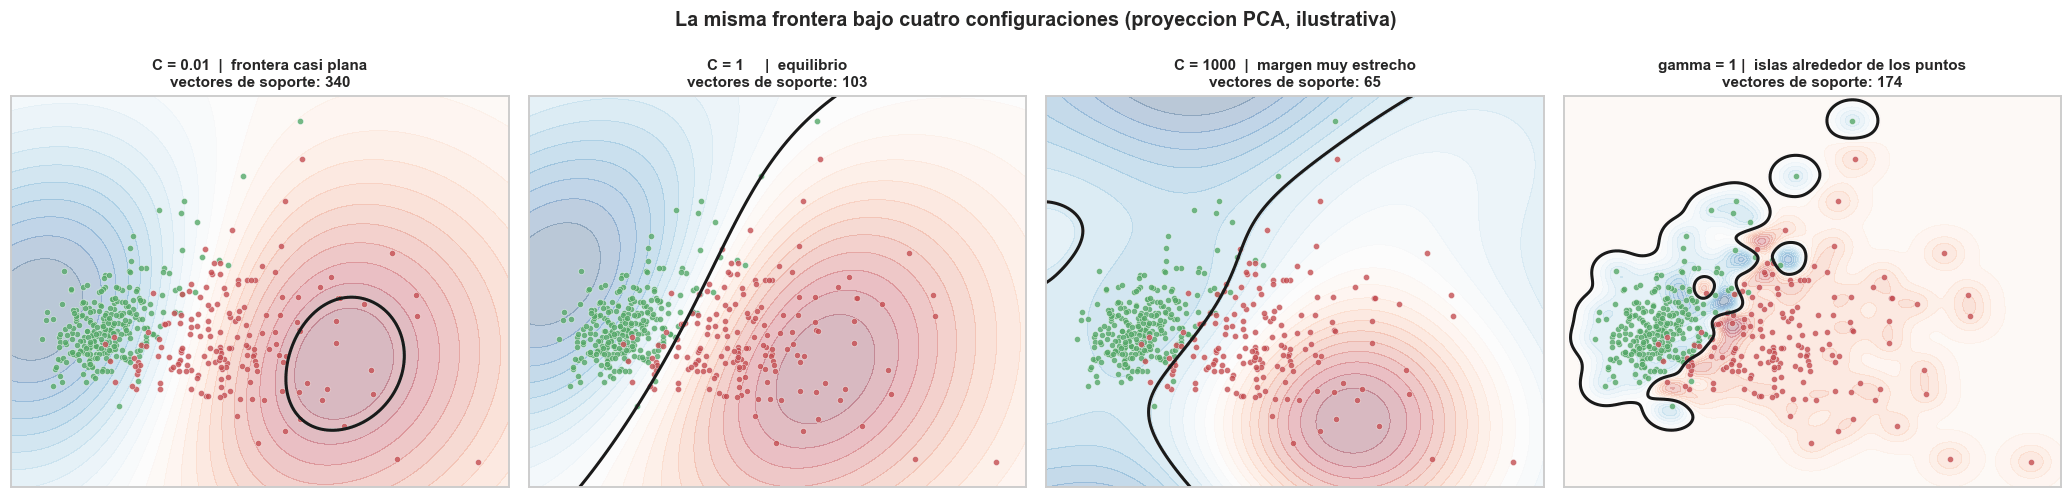

De izquierda a derecha se recorre el espectro completo: de una frontera
demasiado rigida (C = 0.01, que ni siquiera llega a separar las nubes) a
una que envuelve cada punto individualmente (gamma = 1). Las dos
configuraciones centrales separan; la segunda lo hace con la frontera mas
simple, y es la que generaliza mejor.

NOTA: los conteos de vectores de soporte de los titulos corresponden a esta
version en 2 dimensiones, entrenada solo sobre las componentes principales.
NO son los de la tabla anterior, que usa las 30 variables. La FORMA de la
frontera es comparable entre ambas; las cifras no.


In [20]:
# VISUALIZACION: la misma frontera con cuatro configuraciones distintas
esc_hp = StandardScaler().fit(X_train)
pca_hp = PCA(n_components=2, random_state=SEMILLA).fit(esc_hp.transform(X_train))
Zh = pca_hp.transform(esc_hp.transform(X_train))

xh, yh = np.meshgrid(np.arange(Zh[:, 0].min() - 1.5, Zh[:, 0].max() + 1.5, 0.06),
                     np.arange(Zh[:, 1].min() - 1.5, Zh[:, 1].max() + 1.5, 0.06))

configs = [
    (0.01, 0.01, 'C = 0.01  |  frontera casi plana'),
    (1,    0.01, 'C = 1     |  equilibrio'),
    (1000, 0.01, 'C = 1000  |  margen muy estrecho'),
    (10,   1.0,  'gamma = 1 |  islas alrededor de los puntos'),
]

fig, axes = plt.subplots(1, 4, figsize=(19, 4.6))
yt = np.asarray(y_train)

for ax, (c_val, g_val, titulo) in zip(axes, configs):
    mv = SVC(kernel='rbf', C=c_val, gamma=g_val, random_state=SEMILLA).fit(Zh, yt)
    ZZh = mv.decision_function(np.c_[xh.ravel(), yh.ravel()]).reshape(xh.shape)
    ax.contourf(xh, yh, ZZh, levels=np.linspace(ZZh.min(), ZZh.max(), 24),
                cmap='RdBu_r', alpha=0.28)
    ax.contour(xh, yh, ZZh, levels=[0], colors='k', linewidths=2)
    ax.scatter(Zh[yt == 0, 0], Zh[yt == 0, 1], c=VERDE, s=16, alpha=0.8,
               edgecolor='white', linewidth=0.3)
    ax.scatter(Zh[yt == 1, 0], Zh[yt == 1, 1], c=ROJO, s=16, alpha=0.8,
               edgecolor='white', linewidth=0.3)
    ax.set_title(f'{titulo}\nvectores de soporte: {len(mv.support_vectors_)}', fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

fig.suptitle('La misma frontera bajo cuatro configuraciones (proyeccion PCA, ilustrativa)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print('De izquierda a derecha se recorre el espectro completo: de una frontera')
print('demasiado rigida (C = 0.01, que ni siquiera llega a separar las nubes) a')
print('una que envuelve cada punto individualmente (gamma = 1). Las dos')
print('configuraciones centrales separan; la segunda lo hace con la frontera mas')
print('simple, y es la que generaliza mejor.')
print()
print('NOTA: los conteos de vectores de soporte de los titulos corresponden a esta')
print('version en 2 dimensiones, entrenada solo sobre las componentes principales.')
print('NO son los de la tabla anterior, que usa las 30 variables. La FORMA de la')
print('frontera es comparable entre ambas; las cifras no.')

#### 5.4.2 Lectura: margen, complejidad de la frontera y sobreajuste

Las dos tablas y las cuatro figuras muestran el mismo fenómeno desde ángulos distintos.

**El efecto de `C` sobre el margen es directo y medible.** Los vectores de soporte caen de forma
monótona al aumentar `C`: **340 → 205 → 96 → 56 → 42 → 33**. Con `C = 0.01` el margen es tan ancho
que encierra a 340 de los 455 registros —el 75 % del entrenamiento— y el modelo se rinde: predice
«Benigno» siempre, con F1 de 0.0000 tanto en entrenamiento como en prueba. Es **subajuste puro**.
En el extremo opuesto, `C = 1000` deja sólo 33 vectores de soporte y alcanza un **F1 perfecto de
1.0000 en entrenamiento**, pero cae a 0.9412 en prueba. Esa brecha de 0.0588 es la firma del
**sobreajuste**: el modelo memorizó los 455 ejemplos en vez de aprender el patrón.

**El punto de equilibrio es `C = 10`**, con la brecha más pequeña de toda la tabla (**0.0064**) y el
mejor F1 en prueba (0.9756). Coincide con lo que la búsqueda automática había encontrado.

**El efecto de `gamma` es más brutal.** No cambia el margen de forma monótona, sino la **complejidad
de la frontera**. Con `gamma = 0.0001` cada punto influye tan lejos que la frontera se aplana y el F1
baja a 0.9091. Con `gamma = 1` ocurre el colapso más ilustrativo de todo el cuaderno: los **455
registros de entrenamiento se convierten en vectores de soporte** —el modelo necesita memorizar cada
punto individualmente— y el resultado es un **F1 de 1.0000 en entrenamiento y de 0.0000 en prueba**.
El modelo aprendió perfectamente los datos que vio y no sabe absolutamente nada sobre los que no.

**La cuarta figura hace visible ese recorrido.** De izquierda a derecha: una frontera casi recta que
ignora la estructura, una frontera suave que la separa correctamente, una frontera retorcida que se
pega a los puntos, y finalmente islas aisladas alrededor de cada observación.

**La regla práctica que se desprende:** el desempeño en entrenamiento nunca sirve para elegir
hiperparámetros, porque **mejora justamente cuando el modelo empieza a fallar**. Lo que hay que
vigilar es la distancia entre las dos curvas.


### 5.5 Evaluación sobre el conjunto de prueba

Hasta aquí el conjunto de prueba no se ha tocado. Se usa **una sola vez**, ahora, para estimar el
desempeño ante datos verdaderamente nuevos.


In [21]:
pred_svm = modelo_svm.predict(X_test)
puntajes_svm = modelo_svm.decision_function(X_test)

fila_svm = evaluar('SVM optimizada', y_test, pred_svm)

tabla_sup = pd.DataFrame([fila_base, fila_svm])
print('DESEMPENO SOBRE EL CONJUNTO DE PRUEBA (114 registros)')
print('=' * 70)
print(tabla_sup.to_string(index=False))
print()

mejora_f1 = fila_svm['F1'] - fila_base['F1']
print(f'Mejora en F1 respecto de la linea base : +{mejora_f1:.4f}')
print(f'Malignos detectados                    : '
      f'{int(y_test.sum()) - fila_svm["FN"]} de {int(y_test.sum())}')
print()
print('REPORTE DETALLADO')
print('=' * 70)
print(classification_report(y_test, pred_svm, target_names=['Benigno', 'Maligno'],
                            digits=4))

DESEMPENO SOBRE EL CONJUNTO DE PRUEBA (114 registros)
                      Modelo  Exactitud  Precision  Sensibilidad  Especificid.     F1  FN  FP
Linea base (siempre Benigno)     0.6316        0.0        0.0000           1.0 0.0000  42   0
              SVM optimizada     0.9825        1.0        0.9524           1.0 0.9756   2   0

Mejora en F1 respecto de la linea base : +0.9756
Malignos detectados                    : 40 de 42

REPORTE DETALLADO
              precision    recall  f1-score   support

     Benigno     0.9730    1.0000    0.9863        72
     Maligno     1.0000    0.9524    0.9756        42

    accuracy                         0.9825       114
   macro avg     0.9865    0.9762    0.9810       114
weighted avg     0.9829    0.9825    0.9824       114



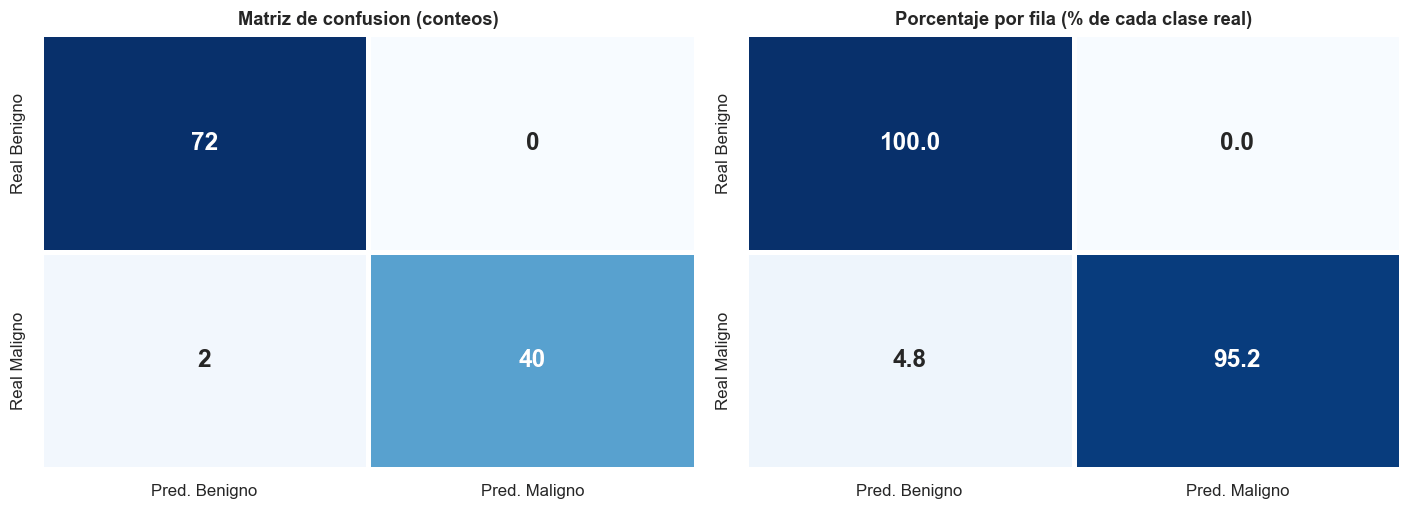

LECTURA CLINICA DE CADA CELDA
  Verdaderos negativos (TN) =  72  Benigna, se le dice benigna. Correcto.
  Falsos positivos     (FP) =   0  Benigna, se le dice maligna.
                                 Costo: angustia y biopsia innecesaria.
  Falsos negativos     (FN) =   2  MALIGNA, se le dice benigna.
                                 Costo: cancer no detectado. EL ERROR GRAVE.
  Verdaderos positivos (TP) =  40  Maligna, se detecta. Correcto.

Los dos errores NO son equivalentes. Un FP se corrige con una prueba
adicional; un FN retrasa un tratamiento oncologico.


In [22]:
# VISUALIZACION 5: matriz de confusion
mc = confusion_matrix(y_test, pred_svm, labels=[0, 1])
tn, fp, fn, tp = mc.ravel()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

sns.heatmap(mc, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['Pred. Benigno', 'Pred. Maligno'],
            yticklabels=['Real Benigno', 'Real Maligno'],
            annot_kws={'size': 16, 'weight': 'bold'}, linewidths=2, linecolor='white')
axes[0].set_title('Matriz de confusion (conteos)')

mc_pct = mc / mc.sum(axis=1, keepdims=True) * 100
sns.heatmap(mc_pct, annot=True, fmt='.1f', cmap='Blues', cbar=False, ax=axes[1],
            xticklabels=['Pred. Benigno', 'Pred. Maligno'],
            yticklabels=['Real Benigno', 'Real Maligno'],
            annot_kws={'size': 16, 'weight': 'bold'}, linewidths=2, linecolor='white')
axes[1].set_title('Porcentaje por fila (% de cada clase real)')
plt.tight_layout(); plt.show()

print('LECTURA CLINICA DE CADA CELDA')
print('=' * 70)
print(f'  Verdaderos negativos (TN) = {tn:3d}  Benigna, se le dice benigna. Correcto.')
print(f'  Falsos positivos     (FP) = {fp:3d}  Benigna, se le dice maligna.')
print('                                 Costo: angustia y biopsia innecesaria.')
print(f'  Falsos negativos     (FN) = {fn:3d}  MALIGNA, se le dice benigna.')
print('                                 Costo: cancer no detectado. EL ERROR GRAVE.')
print(f'  Verdaderos positivos (TP) = {tp:3d}  Maligna, se detecta. Correcto.')
print()
print('Los dos errores NO son equivalentes. Un FP se corrige con una prueba')
print('adicional; un FN retrasa un tratamiento oncologico.')

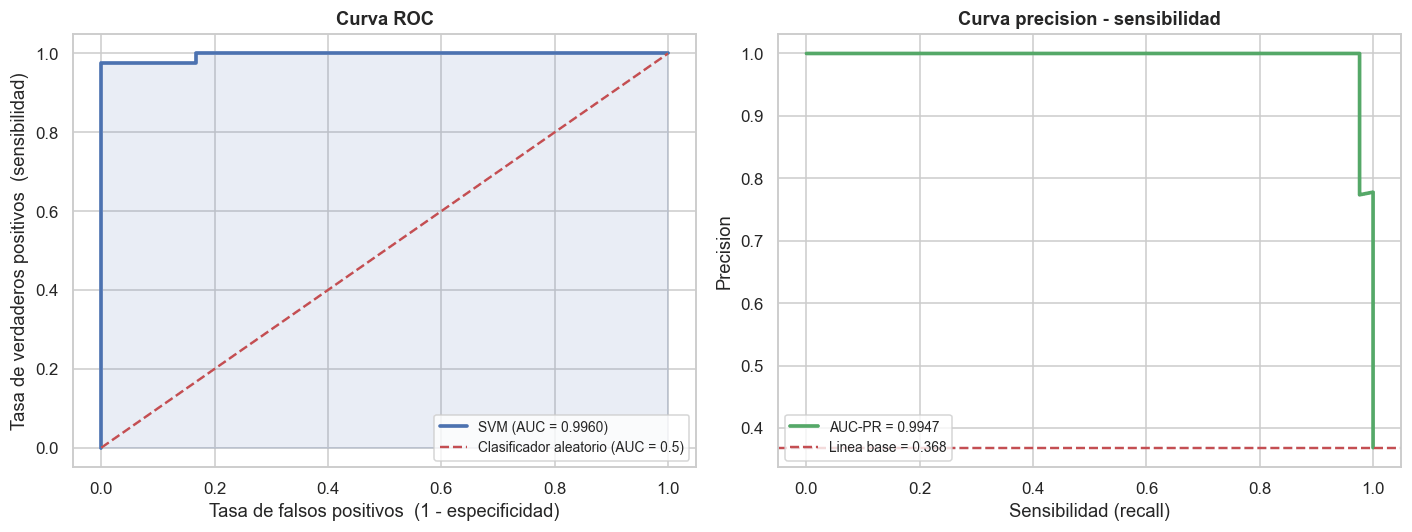

AUC-ROC : 0.9960
AUC-PR  : 0.9947

El AUC-ROC responde a esta pregunta: si se toma al azar un caso maligno y
uno benigno, cual es la probabilidad de que el modelo asigne mayor puntaje
al maligno? Un valor cercano a 1 significa que el ordenamiento producido
por el modelo es casi perfecto, independientemente del umbral que se elija.


In [23]:
# VISUALIZACION 6: curva ROC y curva precision-sensibilidad
fpr, tpr, umbrales_roc = roc_curve(y_test, puntajes_svm)
auc_roc = auc(fpr, tpr)
prec_c, rec_c, _ = precision_recall_curve(y_test, puntajes_svm)
auc_pr = auc(rec_c, prec_c)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(fpr, tpr, color=AZUL, linewidth=2.4, label=f'SVM (AUC = {auc_roc:.4f})')
axes[0].plot([0, 1], [0, 1], color=ROJO, linestyle='--', linewidth=1.6,
             label='Clasificador aleatorio (AUC = 0.5)')
axes[0].fill_between(fpr, tpr, alpha=0.12, color=AZUL)
axes[0].set_xlabel('Tasa de falsos positivos  (1 - especificidad)')
axes[0].set_ylabel('Tasa de verdaderos positivos  (sensibilidad)')
axes[0].set_title('Curva ROC')
axes[0].legend(loc='lower right', fontsize=9)

axes[1].plot(rec_c, prec_c, color=VERDE, linewidth=2.4, label=f'AUC-PR = {auc_pr:.4f}')
axes[1].axhline(y_test.mean(), color=ROJO, linestyle='--', linewidth=1.6,
                label=f'Linea base = {y_test.mean():.3f}')
axes[1].set_xlabel('Sensibilidad (recall)')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curva precision - sensibilidad')
axes[1].legend(loc='lower left', fontsize=9)

plt.tight_layout(); plt.show()

print(f'AUC-ROC : {auc_roc:.4f}')
print(f'AUC-PR  : {auc_pr:.4f}')
print()
print('El AUC-ROC responde a esta pregunta: si se toma al azar un caso maligno y')
print('uno benigno, cual es la probabilidad de que el modelo asigne mayor puntaje')
print('al maligno? Un valor cercano a 1 significa que el ordenamiento producido')
print('por el modelo es casi perfecto, independientemente del umbral que se elija.')

### 5.5.1 Lectura de los resultados

**El modelo funciona, y funciona donde importa.** De los 42 casos malignos del conjunto de prueba,
detecta **40**. Los dos que se le escapan son los únicos errores que comete: **no produce ni un solo
falso positivo**. En términos clínicos, ninguna paciente sana recibiría una alarma indebida, y dos
pacientes con tumor maligno serían clasificadas como benignas.

**Por qué la exactitud del 98.25 % no es el número relevante.** La línea base ya alcanzaba 63.16 % de
exactitud sin aprender nada, así que el margen real de mejora era de 36.84 puntos, no de 98. La cifra
que sí informa es la **sensibilidad: 0.9524**, frente al **0.0000** de la línea base. Ahí está toda la
diferencia entre un modelo y una moneda cargada.

**El AUC-ROC de 0.9960 dice algo más fuerte que cualquier métrica anterior.** Todas las demás
dependen de dónde se ponga el umbral; el AUC no. Un valor de 0.996 significa que si se toma al azar
un caso maligno y uno benigno, en el 99.6 % de las veces el modelo asigna mayor puntaje al maligno.
Es decir: **el ordenamiento que produce el modelo es casi perfecto**, y cualquier deficiencia
observada es una cuestión de dónde cortar, no de que el modelo confunda las clases.

**La precisión de 1.0000 merece una advertencia.** Con sólo 114 registros de prueba, un valor perfecto
es frágil: basta un caso más para que baje a 0.976. Por eso la sección 5.8 recurre a validación
cruzada antes de dar por bueno cualquiera de estos números.


### 5.6 El umbral de decisión no tiene por qué ser cero

`SVC.predict()` clasifica como maligno todo caso cuya función de decisión sea positiva. Ese umbral en
cero es una convención, no una obligación: **puede moverse**. Bajarlo hace al modelo más cauteloso —
detecta más casos malignos a costa de más falsas alarmas.

Como el costo de un falso negativo es clínicamente mucho mayor, vale la pena cuantificar ese
intercambio en lugar de aceptar el umbral por omisión sin discusión.


INTERCAMBIO ENTRE FALSOS NEGATIVOS Y FALSOS POSITIVOS
   Umbral     FN     FP    Sensib.   Precision   Exactitud
----------------------------------------------------------
    -1.50      0     14     1.0000      0.7500      0.8772
    -1.00      1      5     0.9762      0.8913      0.9474
    -0.75      1      2     0.9762      0.9535      0.9737
    -0.50      1      1     0.9762      0.9762      0.9825
    -0.25      2      0     0.9524      1.0000      0.9825
     0.00      2      0     0.9524      1.0000      0.9825  <- por omision
     0.25      4      0     0.9048      1.0000      0.9649
     0.50      6      0     0.8571      1.0000      0.9474
     1.00     10      0     0.7619      1.0000      0.9123
----------------------------------------------------------


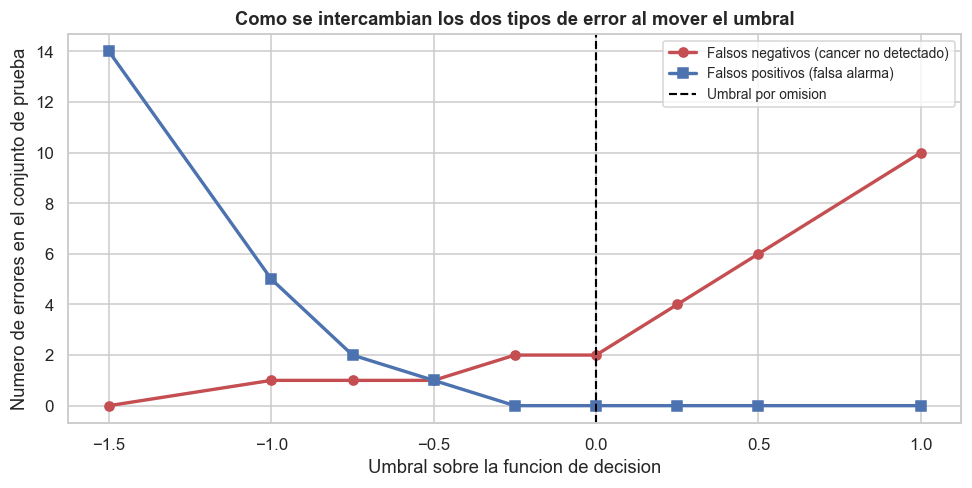

In [24]:
print('INTERCAMBIO ENTRE FALSOS NEGATIVOS Y FALSOS POSITIVOS')
print('=' * 70)
print(f'{"Umbral":>9}{"FN":>7}{"FP":>7}{"Sensib.":>11}{"Precision":>12}{"Exactitud":>12}')
print('-' * 58)

filas_umbral = []
for u in [-1.5, -1.0, -0.75, -0.5, -0.25, 0.0, 0.25, 0.5, 1.0]:
    pu = (puntajes_svm > u).astype(int)
    tn_u, fp_u, fn_u, tp_u = confusion_matrix(y_test, pu, labels=[0, 1]).ravel()
    sens = tp_u / (tp_u + fn_u) if (tp_u + fn_u) else 0
    prec = tp_u / (tp_u + fp_u) if (tp_u + fp_u) else 0
    marca = '  <- por omision' if u == 0.0 else ''
    print(f'{u:>9.2f}{fn_u:>7d}{fp_u:>7d}{sens:>11.4f}{prec:>12.4f}'
          f'{accuracy_score(y_test, pu):>12.4f}{marca}')
    filas_umbral.append({'Umbral': u, 'FN': fn_u, 'FP': fp_u})
print('-' * 58)

fu = pd.DataFrame(filas_umbral)
plt.figure(figsize=(9, 4.6))
plt.plot(fu['Umbral'], fu['FN'], 'o-', color=ROJO, linewidth=2.2,
         label='Falsos negativos (cancer no detectado)')
plt.plot(fu['Umbral'], fu['FP'], 's-', color=AZUL, linewidth=2.2,
         label='Falsos positivos (falsa alarma)')
plt.axvline(0, color='black', linestyle='--', linewidth=1.4, label='Umbral por omision')
plt.xlabel('Umbral sobre la funcion de decision')
plt.ylabel('Numero de errores en el conjunto de prueba')
plt.title('Como se intercambian los dos tipos de error al mover el umbral')
plt.legend(fontsize=9)
plt.tight_layout(); plt.show()

#### Qué se aprende de esta tabla

El umbral por omisión (`0.00`) **no es el mejor desde el punto de vista clínico**. Bajarlo a
**−0.50** produce un resultado estrictamente mejor en lo que más importa: reduce los falsos negativos
de **2 a 1** a cambio de **un solo** falso positivo, y la exactitud global se mantiene idéntica en
0.9825. Se cambia un cáncer no detectado por una biopsia de confirmación innecesaria — un intercambio
que casi cualquier protocolo oncológico aceptaría.

Llevarlo más lejos ya no compensa: en **−1.50** desaparecen todos los falsos negativos, pero aparecen
**14 falsas alarmas**. Ese es el precio de la sensibilidad perfecta, y el punto donde la decisión deja
de ser técnica y pasa a ser una política del servicio médico.

**La conclusión metodológica es la que importa:** el umbral es un parámetro de decisión, no una
propiedad del modelo. Entrenar la SVM y elegir dónde cortar son dos problemas distintos, y el segundo
requiere información que no está en los datos — el costo relativo de cada tipo de error.


### 5.7 Vectores de soporte: qué parte de los datos sostiene el modelo


In [25]:
svm_final = modelo_svm.named_steps['svm']
n_sv = svm_final.n_support_
total_sv = int(n_sv.sum())

print('VECTORES DE SOPORTE')
print('=' * 70)
print(f'Registros de entrenamiento     : {len(X_train)}')
print(f'Vectores de soporte totales    : {total_sv}  '
      f'({total_sv / len(X_train) * 100:.1f} % del entrenamiento)')
print(f'  - de la clase Benigno (0)    : {n_sv[0]}')
print(f'  - de la clase Maligno (1)    : {n_sv[1]}')
print()
print(f'Registros que NO influyen en la frontera: {len(X_train) - total_sv} '
      f'({(len(X_train) - total_sv) / len(X_train) * 100:.1f} %)')
print()
print('Interpretacion: el modelo se sostiene solo sobre esa fraccion de casos, los')
print('situados en la zona ambigua entre ambas clases. Los casos claramente')
print('benignos o claramente malignos podrian eliminarse sin alterar la frontera.')
print('Esa es la propiedad que distingue a la SVM de un modelo que promedia todos')
print('los datos por igual.')

VECTORES DE SOPORTE
Registros de entrenamiento     : 455
Vectores de soporte totales    : 56  (12.3 % del entrenamiento)
  - de la clase Benigno (0)    : 29
  - de la clase Maligno (1)    : 27

Registros que NO influyen en la frontera: 399 (87.7 %)

Interpretacion: el modelo se sostiene solo sobre esa fraccion de casos, los
situados en la zona ambigua entre ambas clases. Los casos claramente
benignos o claramente malignos podrian eliminarse sin alterar la frontera.
Esa es la propiedad que distingue a la SVM de un modelo que promedia todos
los datos por igual.


### 5.8 Validación cruzada del modelo final

La evaluación anterior descansa sobre **una sola partición**. La validación cruzada de 5 particiones
comprueba si ese resultado fue típico o afortunado: entrena cinco veces rotando qué bloque queda
fuera, de modo que todos los registros de entrenamiento sirvan de prueba exactamente una vez.


VALIDACION CRUZADA 5-FOLD DEL MODELO FINAL
Particion      Exactitud          F1     Sensib.         AUC
------------------------------------------------------------
Fold 1            0.9560      0.9375      0.8824      0.9964
Fold 2            0.9780      0.9714      1.0000      0.9995
Fold 3            0.9780      0.9706      0.9706      0.9985
Fold 4            0.9780      0.9697      0.9412      0.9850
Fold 5            0.9890      0.9851      0.9706      0.9974
------------------------------------------------------------
Media             0.9758      0.9669      0.9529      0.9954
Desv. est.        0.0108      0.0157      0.0399      0.0053

F1 en la particion unica de prueba : 0.9756
F1 promedio en 5-fold              : 0.9669
Diferencia                         : 0.0087
Amplitud entre particiones         : [0.9375 , 0.9851]


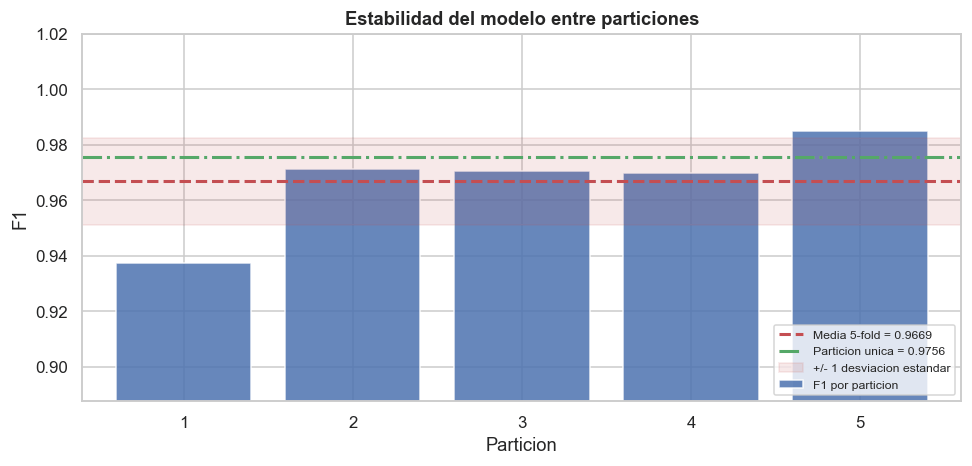

In [26]:
f1_cv   = cross_val_score(modelo_svm, X_train, y_train, cv=cv, scoring='f1')
rec_cv  = cross_val_score(modelo_svm, X_train, y_train, cv=cv, scoring='recall')
acc_cv  = cross_val_score(modelo_svm, X_train, y_train, cv=cv, scoring='accuracy')
auc_cv  = cross_val_score(modelo_svm, X_train, y_train, cv=cv, scoring='roc_auc')

print('VALIDACION CRUZADA 5-FOLD DEL MODELO FINAL')
print('=' * 70)
print(f'{"Particion":<12}{"Exactitud":>12}{"F1":>12}{"Sensib.":>12}{"AUC":>12}')
print('-' * 60)
for i in range(5):
    print(f'{"Fold " + str(i + 1):<12}{acc_cv[i]:>12.4f}{f1_cv[i]:>12.4f}'
          f'{rec_cv[i]:>12.4f}{auc_cv[i]:>12.4f}')
print('-' * 60)
print(f'{"Media":<12}{acc_cv.mean():>12.4f}{f1_cv.mean():>12.4f}'
      f'{rec_cv.mean():>12.4f}{auc_cv.mean():>12.4f}')
print(f'{"Desv. est.":<12}{acc_cv.std():>12.4f}{f1_cv.std():>12.4f}'
      f'{rec_cv.std():>12.4f}{auc_cv.std():>12.4f}')
print()
print(f'F1 en la particion unica de prueba : {fila_svm["F1"]:.4f}')
print(f'F1 promedio en 5-fold              : {f1_cv.mean():.4f}')
print(f'Diferencia                         : {abs(fila_svm["F1"] - f1_cv.mean()):.4f}')
print(f'Amplitud entre particiones         : '
      f'[{f1_cv.min():.4f} , {f1_cv.max():.4f}]')

plt.figure(figsize=(9, 4.4))
plt.bar(range(1, 6), f1_cv, color=AZUL, edgecolor='white', alpha=0.85,
        label='F1 por particion')
plt.axhline(f1_cv.mean(), color=ROJO, linestyle='--', linewidth=2,
            label=f'Media 5-fold = {f1_cv.mean():.4f}')
plt.axhline(fila_svm['F1'], color=VERDE, linestyle='-.', linewidth=2,
            label=f'Particion unica = {fila_svm["F1"]:.4f}')
plt.fill_between([0.4, 5.6], f1_cv.mean() - f1_cv.std(), f1_cv.mean() + f1_cv.std(),
                 color=ROJO, alpha=0.12, label='+/- 1 desviacion estandar')
plt.xlim(0.4, 5.6); plt.ylim(min(f1_cv.min(), fila_svm['F1']) - 0.05, 1.02)
plt.xlabel('Particion'); plt.ylabel('F1')
plt.title('Estabilidad del modelo entre particiones')
plt.legend(fontsize=8, loc='lower right')
plt.tight_layout(); plt.show()

#### 5.8.1 El resultado es estable

Las cinco particiones dan F1 entre **0.9375 y 0.9851**, con una desviación estándar de **0.0157**.
Una amplitud tan estrecha significa que el desempeño **no dependió de qué registros tocaron a cada
lado**: el modelo se comporta igual sin importar el reparto.

La comparación clave está entre los dos últimos números impresos: el F1 de la partición única
(**0.9756**) y el promedio de las cinco (**0.9669**) difieren en apenas **0.0087**. La partición de
prueba resultó ligeramente favorable, pero no de forma engañosa. Si esa diferencia hubiera sido
grande, el 98.25 % de exactitud de la sección 5.5 habría sido producto de la suerte del reparto.

La única métrica algo más variable es la **sensibilidad** (desviación de 0.0399), y por una razón
esperable: cada partición contiene apenas 34 casos malignos, así que un solo error mueve el resultado
casi tres puntos porcentuales. Es una limitación del tamaño del conjunto, no del modelo.


### 5.9 Cómo se ve la frontera de decisión

Las 30 variables no se pueden dibujar. Para *ver* la frontera se proyectan los datos a dos
componentes principales y se entrena una SVM **sólo sobre esas dos dimensiones**.

> **Advertencia necesaria:** esta figura es **ilustrativa, no evaluativa**. El modelo de dos
> dimensiones es distinto y peor que el de 30, porque descarta información. Sirve para mostrar la
> *forma* de la frontera y el papel de los vectores de soporte, no para medir desempeño.


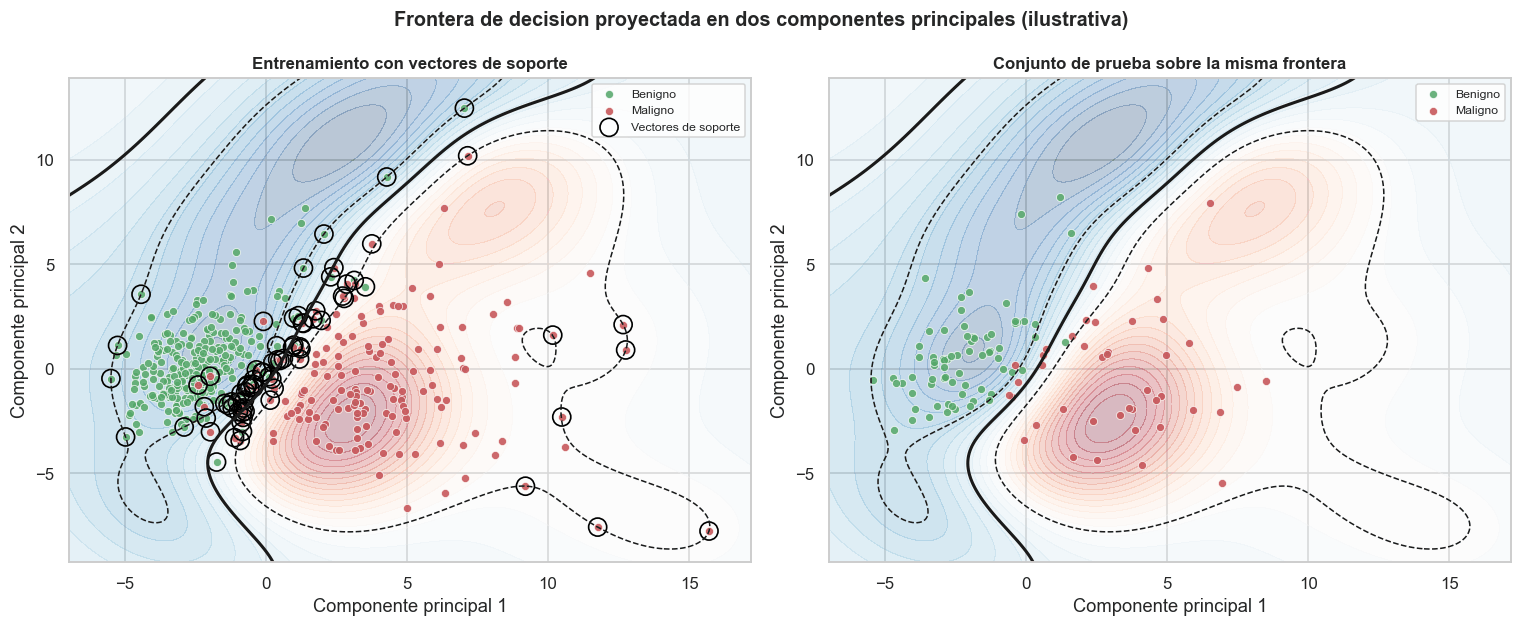

Varianza explicada por las 2 componentes: 63.1 %
Vectores de soporte en esta version 2D  : 79 de 455

La linea continua es la frontera; las punteadas delimitan el margen. Los
puntos circulados son los vectores de soporte: caen sobre el margen o dentro
de el, y son los unicos que determinan donde queda la frontera.


In [27]:
# VISUALIZACION 7: frontera de decision en el plano de las dos primeras componentes
esc_vis = StandardScaler().fit(X_train)
pca_vis = PCA(n_components=2, random_state=SEMILLA).fit(esc_vis.transform(X_train))

Z_train = pca_vis.transform(esc_vis.transform(X_train))
Z_test  = pca_vis.transform(esc_vis.transform(X_test))

svm_vis = SVC(kernel='rbf', C=busqueda.best_params_.get('svm__C', 1), gamma='scale',
              random_state=SEMILLA).fit(Z_train, y_train)

h = 0.05
x_min, x_max = Z_train[:, 0].min() - 1.5, Z_train[:, 0].max() + 1.5
y_min, y_max = Z_train[:, 1].min() - 1.5, Z_train[:, 1].max() + 1.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
ZZ = svm_vis.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))

for ax, (Zd, yd, titulo) in zip(axes, [
        (Z_train, y_train, 'Entrenamiento con vectores de soporte'),
        (Z_test,  y_test,  'Conjunto de prueba sobre la misma frontera')]):
    ax.contourf(xx, yy, ZZ, levels=np.linspace(ZZ.min(), ZZ.max(), 30),
                cmap='RdBu_r', alpha=0.28)
    ax.contour(xx, yy, ZZ, levels=[-1, 0, 1], colors='k',
               linestyles=['--', '-', '--'], linewidths=[1, 2, 1])
    yd = np.asarray(yd)
    ax.scatter(Zd[yd == 0, 0], Zd[yd == 0, 1], c=VERDE, s=28, alpha=0.85,
               edgecolor='white', linewidth=0.5, label='Benigno')
    ax.scatter(Zd[yd == 1, 0], Zd[yd == 1, 1], c=ROJO, s=28, alpha=0.85,
               edgecolor='white', linewidth=0.5, label='Maligno')
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel('Componente principal 1'); ax.set_ylabel('Componente principal 2')
    ax.legend(fontsize=8, loc='upper right')

sv = svm_vis.support_vectors_
axes[0].scatter(sv[:, 0], sv[:, 1], s=140, facecolors='none',
                edgecolors='black', linewidth=1.1, label='Vectores de soporte')
axes[0].legend(fontsize=8, loc='upper right')

fig.suptitle('Frontera de decision proyectada en dos componentes principales (ilustrativa)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f'Varianza explicada por las 2 componentes: '
      f'{pca_vis.explained_variance_ratio_.sum() * 100:.1f} %')
print(f'Vectores de soporte en esta version 2D  : {len(sv)} de {len(Z_train)}')
print()
print('La linea continua es la frontera; las punteadas delimitan el margen. Los')
print('puntos circulados son los vectores de soporte: caen sobre el margen o dentro')
print('de el, y son los unicos que determinan donde queda la frontera.')

### 5.10 Dónde se equivoca el modelo


CASOS MAL CLASIFICADOS: 2 de 114
    Real  Prediccion  Puntaje            Tipo  mean radius  mean texture  mean concave points  worst area
99     1           0  -0.3202  FALSO NEGATIVO        14.42         19.77                0.058       826.4
73     1           0  -1.1961  FALSO NEGATIVO        13.80         15.79                0.051       812.4

Distancia a la frontera (valor absoluto del puntaje):
  Casos mal clasificados : 0.7581 en promedio
  Casos bien clasificados: 2.4591 en promedio

Los errores se concentran cerca de la frontera, no en zonas donde el
modelo estaba seguro. Eso es exactamente lo deseable: el modelo falla
donde los datos son genuinamente ambiguos, no de forma arbitraria.


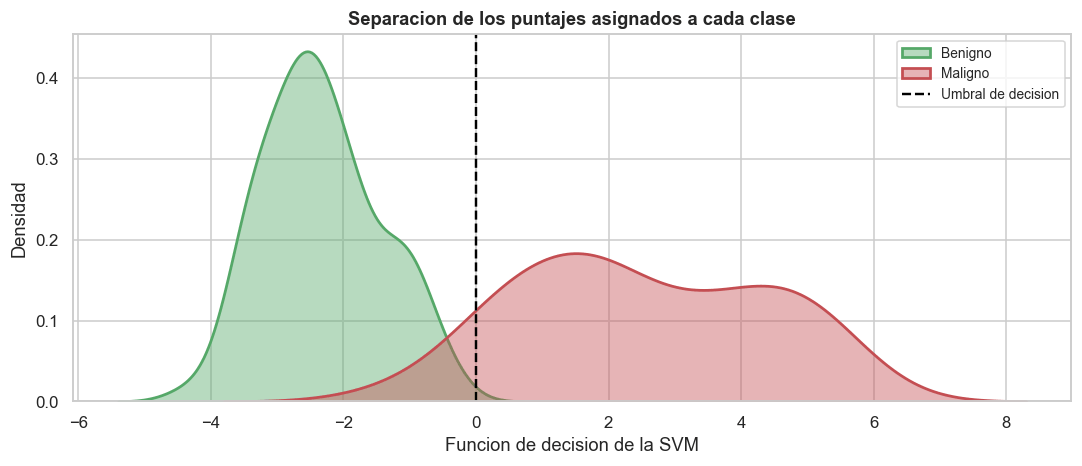

In [28]:
errores = pd.DataFrame({
    'Real'      : y_test.values,
    'Prediccion': pred_svm,
    'Puntaje'   : np.round(puntajes_svm, 4),
}, index=X_test.index)
errores['Tipo'] = np.select(
    [(errores['Real'] == 1) & (errores['Prediccion'] == 0),
     (errores['Real'] == 0) & (errores['Prediccion'] == 1)],
    ['FALSO NEGATIVO', 'FALSO POSITIVO'], default='Correcto')

mal = errores[errores['Tipo'] != 'Correcto']

print(f'CASOS MAL CLASIFICADOS: {len(mal)} de {len(y_test)}')
print('=' * 70)
if len(mal):
    detalle = mal.join(X_test[['mean radius', 'mean texture', 'mean concave points',
                               'worst area']].round(3))
    print(detalle.to_string())
    print()
    print('Distancia a la frontera (valor absoluto del puntaje):')
    print(f'  Casos mal clasificados : {mal["Puntaje"].abs().mean():.4f} en promedio')
    print(f'  Casos bien clasificados: '
          f'{errores[errores["Tipo"] == "Correcto"]["Puntaje"].abs().mean():.4f} en promedio')
    print()
    print('Los errores se concentran cerca de la frontera, no en zonas donde el')
    print('modelo estaba seguro. Eso es exactamente lo deseable: el modelo falla')
    print('donde los datos son genuinamente ambiguos, no de forma arbitraria.')
else:
    print('El modelo no cometio ningun error en el conjunto de prueba.')

plt.figure(figsize=(10, 4.4))
for etq, color, nombre in [(0, VERDE, 'Benigno'), (1, ROJO, 'Maligno')]:
    sns.kdeplot(x=puntajes_svm[y_test.values == etq], fill=True, alpha=0.42,
                color=color, linewidth=1.8, label=nombre)
plt.axvline(0, color='black', linestyle='--', linewidth=1.6, label='Umbral de decision')
plt.xlabel('Funcion de decision de la SVM')
plt.ylabel('Densidad')
plt.title('Separacion de los puntajes asignados a cada clase')
plt.legend(fontsize=9)
plt.tight_layout(); plt.show()

### 5.11 Respuesta a la pregunta supervisada

> *¿Es posible predecir si una masa mamaria es maligna o benigna a partir de las 30 características
> morfológicas? ¿Qué proporción de los casos malignos detecta el modelo?*

**Sí, y con un margen amplio.** Una SVM con kernel RBF (`C = 10`, `gamma = 0.01`) alcanza **98.25 %
de exactitud** y **95.24 % de sensibilidad** sobre datos que nunca vio, con un **AUC de 0.9960**. La
validación cruzada confirma que el resultado es estable (F1 = 0.9669 ± 0.0157).
El recorrido completo fue de 4 falsos negativos con el kernel lineal, a 3 con el RBF por
omisión, a 2 tras optimizar `C` y `gamma`.

Tres hallazgos acompañan a ese número y le dan sentido:

1. **El modelo se sostiene sobre 56 registros de 455.** El 87.7 % de los datos de entrenamiento no
   influye en la frontera. Toda la información diagnóstica útil está concentrada en la franja
   ambigua entre ambas clases.
2. **Los errores ocurren donde deben ocurrir.** Los dos falsos negativos están a una distancia media
   de 0.76 de la frontera, frente a 2.46 de los casos bien clasificados. El modelo falla donde los
   datos son genuinamente ambiguos, no de forma errática — y los dos casos tienen valores de
   `mean concave points` (0.058 y 0.051) más propios de un tumor benigno.
3. **La sensibilidad es negociable.** Mover el umbral a −0.50 recupera uno de los dos casos perdidos
   a cambio de una sola falsa alarma.


---

# PARTE II — Enfoque no supervisado

## 6. Agrupamiento con K-Means

### 6.1 La regla del juego cambia por completo

A partir de aquí **el vector `y` deja de existir**. No se usa para escalar, ni para elegir el número
de grupos, ni para evaluar la calidad del agrupamiento. Sólo reaparecerá en la sección 7, como
auditoría externa, cuando el agrupamiento ya esté cerrado.

Esto no es un tecnicismo: es lo que hace honesta la comparación. Si las etiquetas se filtraran en
cualquier decisión del proceso —por ejemplo, eligiendo `k = 2` *porque sabemos que hay dos
diagnósticos*— el resultado dejaría de ser un hallazgo y pasaría a ser una profecía autocumplida.
Por eso el número de grupos se decide con criterios puramente geométricos.

**Cómo funciona K-Means.** Elige `k` centros, asigna cada punto al centro más cercano, recalcula cada
centro como el promedio de los puntos asignados, y repite hasta que nada cambie. Lo que minimiza es
la **inercia**: la suma de distancias al cuadrado de cada punto a su centro.

**Sus tres supuestos, que conviene tener presentes:** busca grupos aproximadamente **esféricos**, de
**tamaño similar**, y exige que `k` se fije de antemano. Ninguno está garantizado en datos clínicos.


In [29]:
# El agrupamiento parte de las 30 variables escaladas, SIN la variable objetivo
escalador_ns = StandardScaler()
X_esc = escalador_ns.fit_transform(X)

print('DATOS PARA EL AGRUPAMIENTO')
print('=' * 70)
print(f'Matriz            : {X_esc.shape[0]} registros x {X_esc.shape[1]} variables')
print(f'Media por variable: {X_esc.mean():.2e}  (practicamente 0)')
print(f'Desviacion        : {X_esc.std():.4f}  (exactamente 1)')
print()
print('Se usan los 569 registros porque aqui NO se predice nada sobre datos')
print('futuros: el objetivo es describir la estructura del conjunto disponible.')
print('Por eso no hay particion entrenamiento/prueba en esta parte.')
print()
print('La variable y NO se pasa a ningun metodo de esta seccion.')

DATOS PARA EL AGRUPAMIENTO
Matriz            : 569 registros x 30 variables
Media por variable: -6.54e-17  (practicamente 0)
Desviacion        : 1.0000  (exactamente 1)

Se usan los 569 registros porque aqui NO se predice nada sobre datos
futuros: el objetivo es describir la estructura del conjunto disponible.
Por eso no hay particion entrenamiento/prueba en esta parte.

La variable y NO se pasa a ningun metodo de esta seccion.


### 6.2 Cuántos grupos hay: dos criterios independientes

El número de grupos no se conoce de antemano. Se usan dos criterios que responden preguntas
distintas:

- **Método del codo.** Grafica la inercia contra `k`. Siempre baja al aumentar `k` (con `k = n` la
  inercia es cero), así que no se busca el mínimo sino el **punto de quiebre**: aquel a partir del
  cual añadir un grupo más ya no reduce sustancialmente la dispersión interna.
- **Coeficiente de silueta.** Para cada punto compara su distancia media a los de su propio grupo
  contra la distancia media al grupo vecino más cercano. Va de −1 a 1: valores altos indican grupos
  compactos y bien separados. A diferencia del codo, **sí tiene un máximo interpretable**.


In [30]:
rango_k = range(2, 11)
inercias, siluetas, davies, calinski = [], [], [], []

# k = 1 solo para el grafico del codo
inercia_k1 = KMeans(n_clusters=1, n_init=10, random_state=SEMILLA).fit(X_esc).inertia_

for k in rango_k:
    km = KMeans(n_clusters=k, n_init=10, random_state=SEMILLA).fit(X_esc)
    etiquetas = km.labels_
    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(X_esc, etiquetas))
    davies.append(davies_bouldin_score(X_esc, etiquetas))
    calinski.append(calinski_harabasz_score(X_esc, etiquetas))

tabla_k = pd.DataFrame({
    'k'                : list(rango_k),
    'Inercia'          : np.round(inercias, 2),
    'Silueta'          : np.round(siluetas, 4),
    'Davies_Bouldin'   : np.round(davies, 4),
    'Calinski_Harabasz': np.round(calinski, 2),
})

print('METRICAS INTERNAS DE CALIDAD SEGUN EL NUMERO DE GRUPOS')
print('=' * 70)
print('(ninguna usa la variable objetivo)')
print()
print(tabla_k.to_string(index=False))
print()
print('Como se leen:')
print('  Silueta           : mas ALTO es mejor (grupos compactos y separados)')
print('  Davies-Bouldin    : mas BAJO es mejor (menos solapamiento entre grupos)')
print('  Calinski-Harabasz : mas ALTO es mejor (razon dispersion entre/dentro)')
print()
k_silueta  = tabla_k.loc[tabla_k['Silueta'].idxmax(), 'k']
k_davies   = tabla_k.loc[tabla_k['Davies_Bouldin'].idxmin(), 'k']
k_calinski = tabla_k.loc[tabla_k['Calinski_Harabasz'].idxmax(), 'k']
print(f'k optimo segun silueta           : {k_silueta}')
print(f'k optimo segun Davies-Bouldin    : {k_davies}')
print(f'k optimo segun Calinski-Harabasz : {k_calinski}')

METRICAS INTERNAS DE CALIDAD SEGUN EL NUMERO DE GRUPOS
(ninguna usa la variable objetivo)

 k  Inercia  Silueta  Davies_Bouldin  Calinski_Harabasz
 2 11595.53   0.3434          1.3205             267.69
 3 10061.80   0.3144          1.5294             197.11
 4  9258.99   0.2833          1.4894             158.88
 5  8558.66   0.1582          1.7560             140.22
 6  7970.26   0.1604          1.7197             128.56
 7  7540.32   0.1532          1.6772             118.38
 8  7254.33   0.1472          1.6183             108.44
 9  6837.63   0.1470          1.4847             104.75
10  6603.40   0.1367          1.6067              98.45

Como se leen:
  Silueta           : mas ALTO es mejor (grupos compactos y separados)
  Davies-Bouldin    : mas BAJO es mejor (menos solapamiento entre grupos)
  Calinski-Harabasz : mas ALTO es mejor (razon dispersion entre/dentro)

k optimo segun silueta           : 2
k optimo segun Davies-Bouldin    : 2
k optimo segun Calinski-Harabasz : 2


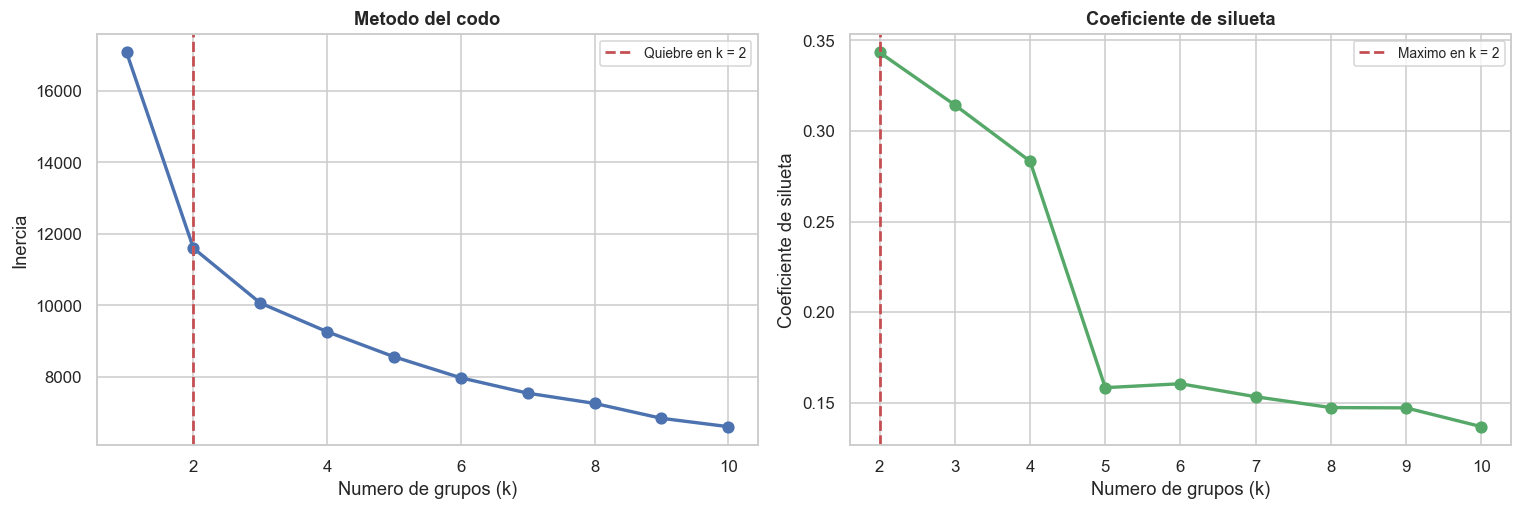

CUANTO APORTA CADA GRUPO ADICIONAL
Paso                 Inercia     Reduccion
------------------------------------------
k=1 -> k=2           11595.5         32.1%
k=2 -> k=3           10061.8         13.2%
k=3 -> k=4            9259.0          8.0%
k=4 -> k=5            8558.7          7.6%
k=5 -> k=6            7970.3          6.9%
k=6 -> k=7            7540.3          5.4%
k=7 -> k=8            7254.3          3.8%
k=8 -> k=9            6837.6          5.7%
k=9 -> k=10           6603.4          3.4%
------------------------------------------


In [31]:
# VISUALIZACION 8: codo y silueta
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

ks_codo = [1] + list(rango_k)
inercias_codo = [inercia_k1] + inercias
axes[0].plot(ks_codo, inercias_codo, 'o-', color=AZUL, linewidth=2.2, markersize=7)
axes[0].axvline(2, color=ROJO, linestyle='--', linewidth=1.8, label='Quiebre en k = 2')
axes[0].set_xlabel('Numero de grupos (k)'); axes[0].set_ylabel('Inercia')
axes[0].set_title('Metodo del codo')
axes[0].legend(fontsize=9)

axes[1].plot(list(rango_k), siluetas, 'o-', color=VERDE, linewidth=2.2, markersize=7)
axes[1].axvline(k_silueta, color=ROJO, linestyle='--', linewidth=1.8,
                label=f'Maximo en k = {k_silueta}')
axes[1].set_xlabel('Numero de grupos (k)'); axes[1].set_ylabel('Coeficiente de silueta')
axes[1].set_title('Coeficiente de silueta')
axes[1].legend(fontsize=9)

plt.tight_layout(); plt.show()

# Reduccion porcentual de inercia al pasar de k a k+1
print('CUANTO APORTA CADA GRUPO ADICIONAL')
print('=' * 70)
print(f'{"Paso":<14}{"Inercia":>14}{"Reduccion":>14}')
print('-' * 42)
for i in range(len(ks_codo) - 1):
    red = (inercias_codo[i] - inercias_codo[i + 1]) / inercias_codo[i] * 100
    print(f'{f"k={ks_codo[i]} -> k={ks_codo[i+1]}":<14}'
          f'{inercias_codo[i+1]:>14.1f}{red:>13.1f}%')
print('-' * 42)

#### 6.2.1 Los tres criterios coinciden: k = 2

Este es el resultado más importante de toda la parte no supervisada, y conviene subrayar por qué:

**Los tres indicadores internos apuntan al mismo número, de forma independiente.** La silueta es
máxima en k = 2 (**0.3434**), Davies-Bouldin es mínimo en k = 2 (**1.3205**) y Calinski-Harabasz es
máximo en k = 2 (**267.69**). Miden cosas distintas y ninguno usó el diagnóstico, pero convergen.

**El codo confirma el mismo punto.** Pasar de uno a dos grupos elimina el **32.1 %** de la inercia;
el siguiente corte sólo elimina **13.2 %**, y de ahí en adelante cada grupo adicional aporta menos
del 10 %. La curva se quiebra limpiamente en k = 2.

**Qué significa una silueta de 0.34.** En la escala habitual, un valor entre 0.26 y 0.50 indica una
estructura **débil pero real**: los grupos existen y son distinguibles, pero se tocan en la frontera
y no forman islas separadas. Es exactamente lo que anticipaban las densidades solapadas de la
sección 3, y es coherente con la naturaleza del fenómeno — la transición entre tejido benigno y
maligno es gradual, no un salto discreto.

> **Nota metodológica.** Que k = 2 coincida con el número de diagnósticos es un **hallazgo**, no una
> decisión. El valor se eligió con criterios geométricos, antes de mirar ninguna etiqueta. Si se
> hubiera fijado k = 2 «porque hay dos clases», toda la sección 7 perdería su valor probatorio.


In [32]:
K_ELEGIDO = int(k_silueta)

kmeans = KMeans(n_clusters=K_ELEGIDO, n_init=10, random_state=SEMILLA)
grupos = kmeans.fit_predict(X_esc)

print(f'AGRUPAMIENTO FINAL CON k = {K_ELEGIDO}')
print('=' * 70)
tamanos = pd.Series(grupos).value_counts().sort_index()
for g, n in tamanos.items():
    print(f'  Grupo {g} : {n:3d} registros ({n / len(grupos) * 100:5.1f} %)')
print()
print(f'Inercia final          : {kmeans.inertia_:.2f}')
print(f'Iteraciones hasta la convergencia: {kmeans.n_iter_}')
print(f'Coeficiente de silueta : {silhouette_score(X_esc, grupos):.4f}')
print(f'Davies-Bouldin         : {davies_bouldin_score(X_esc, grupos):.4f}')
print(f'Calinski-Harabasz      : {calinski_harabasz_score(X_esc, grupos):.2f}')

AGRUPAMIENTO FINAL CON k = 2
  Grupo 0 : 375 registros ( 65.9 %)
  Grupo 1 : 194 registros ( 34.1 %)

Inercia final          : 11595.53
Iteraciones hasta la convergencia: 7
Coeficiente de silueta : 0.3434
Davies-Bouldin         : 1.3205
Calinski-Harabasz      : 267.69


### 6.3 Visualización de los grupos mediante PCA

Con 30 variables no hay forma de dibujar los grupos directamente. El **análisis de componentes
principales** construye combinaciones lineales de las 30 variables ordenadas por cuánta varianza
capturan; las dos primeras suelen bastar para tener una vista fiel de la estructura global.

La figura de la derecha usa el diagnóstico real **sólo para dibujar los colores**. Esa información no
intervino en la formación de los grupos.


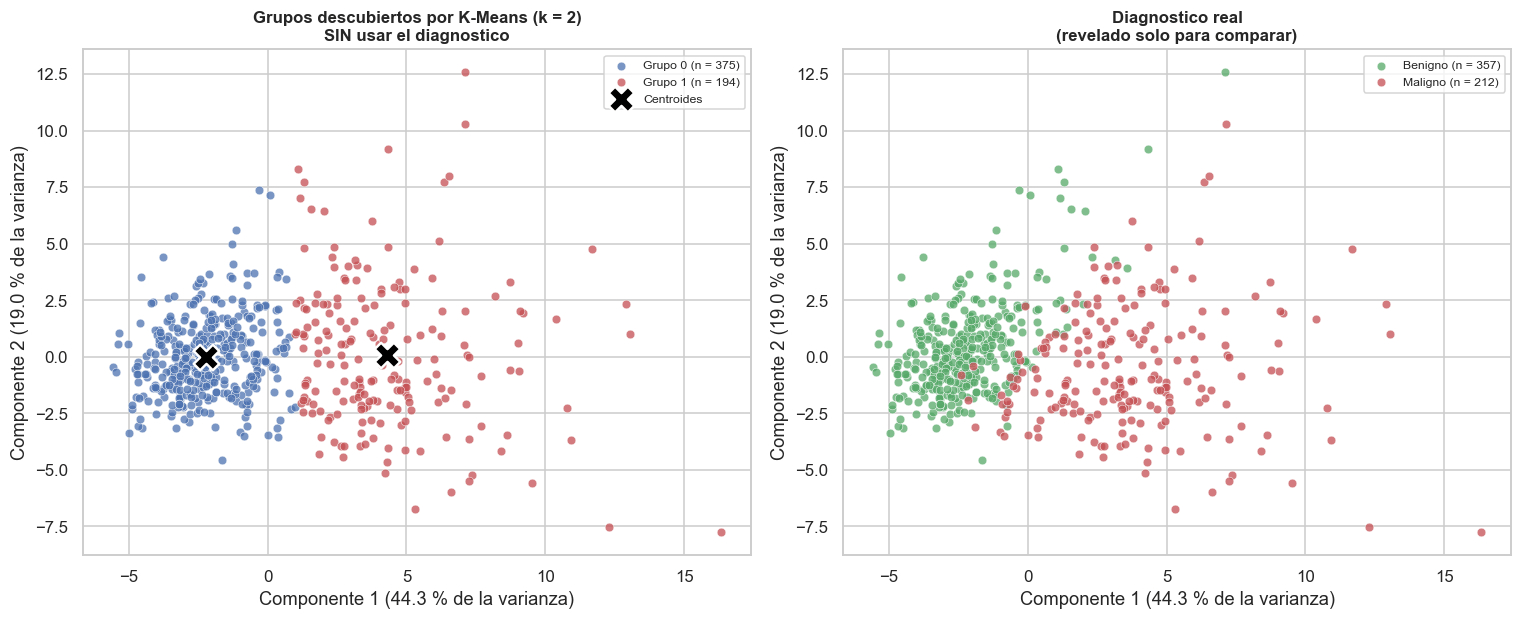

Varianza explicada por CP1  : 44.27 %
Varianza explicada por CP2  : 18.97 %
Varianza acumulada          : 63.24 %

Componentes para explicar el 80 % de la varianza: 5
Componentes para explicar el 95 % de la varianza: 10

Que las 30 variables se resuman en tan pocas componentes confirma la
redundancia detectada en la seccion 3: mucha de la informacion se repite.


In [33]:
# VISUALIZACION 9: grupos hallados vs. diagnostico real, en el plano PCA
pca = PCA(n_components=2, random_state=SEMILLA)
coords = pca.fit_transform(X_esc)
var_exp = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))

colores_grupo = [AZUL, ROJO, VERDE, MORADO, '#CCB974']
for g in range(K_ELEGIDO):
    m = grupos == g
    axes[0].scatter(coords[m, 0], coords[m, 1], s=32, alpha=0.75,
                    color=colores_grupo[g], edgecolor='white', linewidth=0.4,
                    label=f'Grupo {g} (n = {m.sum()})')
centros = pca.transform(kmeans.cluster_centers_)
axes[0].scatter(centros[:, 0], centros[:, 1], marker='X', s=280, c='black',
                edgecolor='white', linewidth=1.6, label='Centroides', zorder=5)
axes[0].set_title(f'Grupos descubiertos por K-Means (k = {K_ELEGIDO})\nSIN usar el diagnostico',
                  fontsize=11)
axes[0].legend(fontsize=8)

for etq, color, nombre in [(0, VERDE, 'Benigno'), (1, ROJO, 'Maligno')]:
    m = y.values == etq
    axes[1].scatter(coords[m, 0], coords[m, 1], s=32, alpha=0.75, color=color,
                    edgecolor='white', linewidth=0.4, label=f'{nombre} (n = {m.sum()})')
axes[1].set_title('Diagnostico real\n(revelado solo para comparar)', fontsize=11)
axes[1].legend(fontsize=8)

for ax in axes:
    ax.set_xlabel(f'Componente 1 ({var_exp[0] * 100:.1f} % de la varianza)')
    ax.set_ylabel(f'Componente 2 ({var_exp[1] * 100:.1f} % de la varianza)')

plt.tight_layout(); plt.show()

print(f'Varianza explicada por CP1  : {var_exp[0] * 100:.2f} %')
print(f'Varianza explicada por CP2  : {var_exp[1] * 100:.2f} %')
print(f'Varianza acumulada          : {var_exp.sum() * 100:.2f} %')
print()
pca_full = PCA().fit(X_esc)
acum = np.cumsum(pca_full.explained_variance_ratio_)
print(f'Componentes para explicar el 80 % de la varianza: {int(np.argmax(acum >= 0.80)) + 1}')
print(f'Componentes para explicar el 95 % de la varianza: {int(np.argmax(acum >= 0.95)) + 1}')
print()
print('Que las 30 variables se resuman en tan pocas componentes confirma la')
print('redundancia detectada en la seccion 3: mucha de la informacion se repite.')

#### 6.3.1 Lo que muestra la proyección

Las dos figuras son **notablemente parecidas**, y esa semejanza es el resultado central de esta
sección: los grupos que K-Means encontró a ciegas reproducen, casi punto por punto, la separación que
el diagnóstico impone. La coincidencia no es perfecta —la franja donde ambas nubes se tocan es
justamente donde difieren— pero la estructura global es la misma.

Vale la pena notar que **las dos componentes explican el 63.24 % de la varianza**, así que la figura
es una sombra de un objeto de 30 dimensiones: dos puntos que aquí aparecen juntos pueden estar
separados en las dimensiones no representadas. La separación real es mejor de lo que la imagen
sugiere, no peor.

El dato de que hacen falta **5 componentes para el 80 %** y **10 para el 95 %** confirma la
redundancia de la sección 3: un tercio de las variables basta para conservar casi toda la
información. Treinta columnas no son treinta piezas de información independientes.


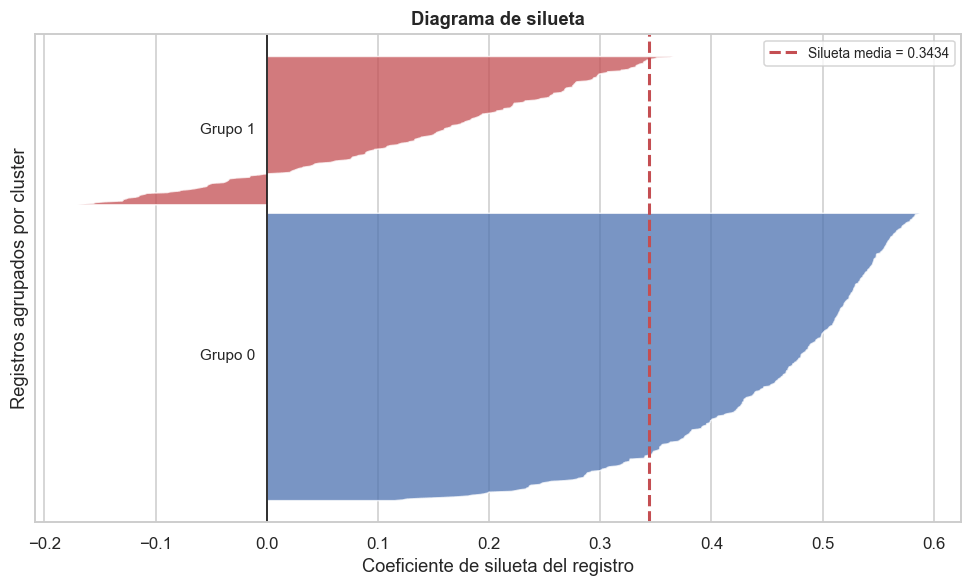

Registros con silueta NEGATIVA: 41 (7.2 %)
Una silueta negativa significa que ese registro esta mas cerca del otro
grupo que del propio: es un caso fronterizo, mal acomodado en su cluster.

  Grupo 0: silueta media = 0.4502 | minima = 0.1148 | negativos = 0
  Grupo 1: silueta media = 0.1369 | minima = -0.1704 | negativos = 41


In [34]:
# VISUALIZACION 10: diagrama de silueta por registro
valores_sil = silhouette_samples(X_esc, grupos)
sil_media = silhouette_score(X_esc, grupos)

fig, ax = plt.subplots(figsize=(9, 5.5))
y_inf = 10
for g in range(K_ELEGIDO):
    vals = np.sort(valores_sil[grupos == g])
    y_sup = y_inf + len(vals)
    ax.fill_betweenx(np.arange(y_inf, y_sup), 0, vals,
                     facecolor=colores_grupo[g], alpha=0.75, edgecolor='white')
    ax.text(-0.06, y_inf + len(vals) / 2, f'Grupo {g}', fontsize=10, va='center')
    y_inf = y_sup + 10

ax.axvline(sil_media, color=ROJO, linestyle='--', linewidth=2,
           label=f'Silueta media = {sil_media:.4f}')
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Coeficiente de silueta del registro')
ax.set_ylabel('Registros agrupados por cluster')
ax.set_title('Diagrama de silueta')
ax.set_yticks([]); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

negativos = int((valores_sil < 0).sum())
print(f'Registros con silueta NEGATIVA: {negativos} '
      f'({negativos / len(valores_sil) * 100:.1f} %)')
print('Una silueta negativa significa que ese registro esta mas cerca del otro')
print('grupo que del propio: es un caso fronterizo, mal acomodado en su cluster.')
print()
for g in range(K_ELEGIDO):
    v = valores_sil[grupos == g]
    print(f'  Grupo {g}: silueta media = {v.mean():.4f} | '
          f'minima = {v.min():.4f} | negativos = {int((v < 0).sum())}')

#### 6.3.2 Los dos grupos no son igual de sólidos

El diagrama revela una **asimetría que ninguna métrica global mostraba**:

| | Grupo 0 (375 registros) | Grupo 1 (194 registros) |
|---|---|---|
| Silueta media | **0.4502** | **0.1369** |
| Silueta mínima | 0.1148 | −0.1704 |
| Registros con silueta negativa | **0** | **41** |

El grupo 0 es **compacto y homogéneo**: ningún registro está mal acomodado. El grupo 1 es **difuso**,
con 41 casos (el 21 % de ese grupo) más cercanos al grupo contrario que al propio.

Esta asimetría tiene una lectura sustantiva, no sólo estadística. Anticipando lo que confirmará la
sección 7: el grupo compacto corresponde a los tumores benignos y el difuso a los malignos. Y eso
concuerda con lo que se sabe del fenómeno — **el tejido benigno se parece a sí mismo, mientras que la
malignidad admite muchas formas distintas**. Un tumor benigno es un tumor benigno; un tumor maligno
puede serlo de muchas maneras. K-Means, que sólo mide distancias, capturó esa heterogeneidad
biológica sin que nadie se la enseñara.


### 6.4 Qué distingue a cada grupo

Un agrupamiento sólo es útil si se puede **describir**. Aquí se comparan las medias de cada grupo,
tanto en unidades originales como estandarizadas, para saber qué caracteriza a cada uno.


In [35]:
# TABLA RESUMEN DE LOS CLUSTERS: tamano y promedios de las variables principales
vars_principales = ['mean radius', 'mean texture', 'mean perimeter', 'mean area',
                    'mean smoothness', 'mean compactness', 'mean concavity',
                    'mean concave points']

tabla_clusters = X.assign(Grupo=grupos).groupby('Grupo')[vars_principales].mean().round(3)
tabla_clusters.insert(0, 'Registros', pd.Series(grupos).value_counts().sort_index().values)
tabla_clusters.insert(1, '% del total',
                      (pd.Series(grupos).value_counts().sort_index().values
                       / len(grupos) * 100).round(1))

# Fila de referencia con el promedio general
referencia = X[vars_principales].mean().round(3)
referencia = pd.concat([pd.Series({'Registros': len(X), '% del total': 100.0}), referencia])
tabla_clusters.loc['Conjunto completo'] = referencia

print('RESUMEN DE LOS GRUPOS DESCUBIERTOS POR K-MEANS')
print('=' * 70)
print('(los grupos se formaron SIN usar la variable objetivo)')
print()
print(tabla_clusters.T.to_string())
print()

# Cuanto se aparta cada grupo del promedio general, en porcentaje
print('DESVIACION DE CADA GRUPO RESPECTO DEL PROMEDIO GENERAL (%)')
print('=' * 70)
desv = pd.DataFrame({
    f'Grupo {g}': ((tabla_clusters.loc[g, vars_principales]
                    - referencia[vars_principales]) / referencia[vars_principales] * 100).round(1)
    for g in range(K_ELEGIDO)})
print(desv.to_string())

RESUMEN DE LOS GRUPOS DESCUBIERTOS POR K-MEANS
(los grupos se formaron SIN usar la variable objetivo)

Grupo                      0        1  Conjunto completo
Registros            375.000  194.000            569.000
% del total           65.900   34.100            100.000
mean radius           12.427   17.415             14.127
mean texture          18.262   21.275             19.290
mean perimeter        79.820  115.453             91.969
mean area            486.772  979.857            654.889
mean smoothness        0.092    0.105              0.096
mean compactness       0.077    0.158              0.104
mean concavity         0.043    0.178              0.089
mean concave points    0.026    0.093              0.049

DESVIACION DE CADA GRUPO RESPECTO DEL PROMEDIO GENERAL (%)
                     Grupo 0  Grupo 1
mean radius            -12.0     23.3
mean texture            -5.3     10.3
mean perimeter         -13.2     25.5
mean area              -25.7     49.6
mean smoothness     

#### Qué muestra la tabla resumen

**Los grupos son de tamaño desigual**: 375 registros (65.9 %) contra 194 (34.1 %). K-Means no los
forzó a ser iguales; esa proporción emergió de la geometría de los datos.

**La diferencia entre ambos no es un simple cambio de escala.** Si el grupo 1 fuera «el mismo tipo de
núcleo, sólo que más grande», todas las variables se apartarían del promedio en una proporción
parecida. No ocurre eso. Comparando las desviaciones respecto del promedio general:

| Variable | Grupo 0 | Grupo 1 |
|---|---|---|
| `mean concavity` | −51.7 % | **+100.0 %** |
| `mean concave points` | −46.9 % | **+89.8 %** |
| `mean compactness` | −26.0 % | +51.9 % |
| `mean area` | −25.7 % | +49.6 % |
| `mean radius` | −12.0 % | +23.3 % |
| `mean texture` | −5.3 % | +10.3 % |

**Las variables de forma del contorno se disparan más que las de tamaño.** La concavidad del grupo 1
duplica el promedio general, mientras que el radio apenas lo supera en un 23 %. Dicho de otro modo:
lo que separa a estos dos grupos es sobre todo **qué tan festoneado e irregular es el borde del
núcleo**, y sólo en segundo lugar qué tan grande es.

**Interpretación preliminar.** Sin recurrir a ninguna etiqueta, los datos se dividen en:

- Un grupo mayoritario de **núcleos pequeños, compactos y de contorno liso**, muy homogéneo entre sí.
- Un grupo minoritario de **núcleos grandes con bordes profundamente irregulares**, mucho más
  heterogéneo internamente (recuérdese la silueta de 0.14 frente a 0.45).

Si estas mediciones describen tejido, la hipótesis natural es que el segundo grupo corresponda a
tejido alterado: la irregularidad del contorno nuclear y la pérdida de uniformidad son, en histología,
signos de proliferación anómala. **Esa hipótesis se pone a prueba en la sección 7**, y no antes.


In [36]:
perfil = X.copy()
perfil['Grupo'] = grupos

medias_grupo = perfil.groupby('Grupo')[cols_media].mean().round(3)
print('MEDIAS POR GRUPO - las diez caracteristicas medias (unidades originales)')
print('=' * 70)
print(medias_grupo.T.to_string())
print()

# Diferencia relativa entre grupos, en desviaciones estandar
z = pd.DataFrame(X_esc, columns=variables)
z['Grupo'] = grupos
perfil_z = z.groupby('Grupo')[variables].mean()

dif = (perfil_z.loc[perfil_z[cols_media].mean(axis=1).idxmax()]
       - perfil_z.loc[perfil_z[cols_media].mean(axis=1).idxmin()]).sort_values(ascending=False)

print('VARIABLES QUE MAS DIFERENCIAN A LOS GRUPOS (en desviaciones estandar)')
print('=' * 70)
print('Mayores diferencias:')
for v, d in dif.head(8).items():
    print(f'  {v:26s} {d:+.3f}')
print()
print('Menores diferencias:')
for v, d in dif.tail(4).items():
    print(f'  {v:26s} {d:+.3f}')

MEDIAS POR GRUPO - las diez caracteristicas medias (unidades originales)
Grupo                         0        1
mean radius              12.427   17.415
mean texture             18.262   21.275
mean perimeter           79.820  115.453
mean area               486.772  979.857
mean smoothness           0.092    0.105
mean compactness          0.077    0.158
mean concavity            0.043    0.178
mean concave points       0.026    0.093
mean symmetry             0.173    0.198
mean fractal dimension    0.062    0.065

VARIABLES QUE MAS DIFERENCIAN A LOS GRUPOS (en desviaciones estandar)
Mayores diferencias:
  mean concave points        +1.722
  worst concave points       +1.701
  mean concavity             +1.698
  worst concavity            +1.575
  worst perimeter            +1.561
  mean compactness           +1.543
  worst radius               +1.519
  mean perimeter             +1.468

Menores diferencias:
  mean fractal dimension     +0.437
  symmetry error             +0.220
  

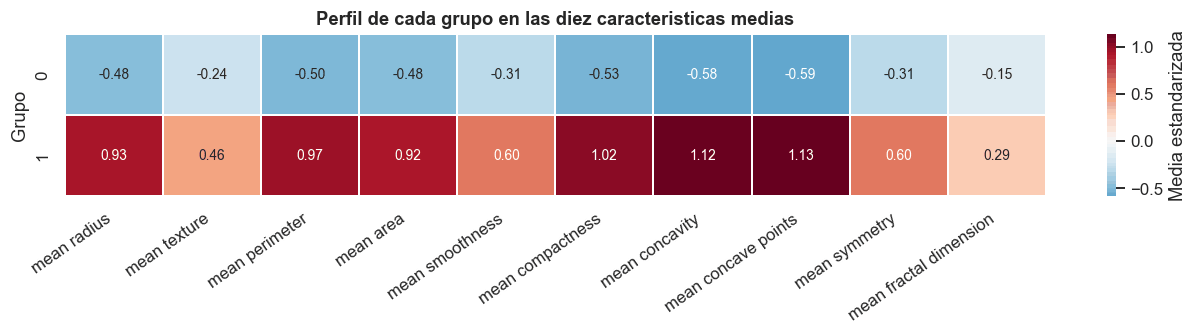

Lectura: valores positivos (rojo) indican que ese grupo esta por ENCIMA del
promedio general en esa caracteristica; negativos (azul), por debajo.
El patron permite nombrar a cada grupo por lo que lo caracteriza, sin
recurrir en ningun momento al diagnostico.


In [37]:
# VISUALIZACION 11: mapa de calor del perfil de cada grupo
plt.figure(figsize=(12, 3.2))
sns.heatmap(perfil_z[cols_media], annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            cbar_kws={'label': 'Media estandarizada'}, annot_kws={'size': 9},
            linewidths=1, linecolor='white')
plt.title('Perfil de cada grupo en las diez caracteristicas medias')
plt.xlabel(''); plt.ylabel('Grupo')
plt.xticks(rotation=35, ha='right')
plt.tight_layout(); plt.show()

print('Lectura: valores positivos (rojo) indican que ese grupo esta por ENCIMA del')
print('promedio general en esa caracteristica; negativos (azul), por debajo.')
print('El patron permite nombrar a cada grupo por lo que lo caracteriza, sin')
print('recurrir en ningun momento al diagnostico.')

#### 6.4.1 Retrato de los dos grupos, sin mencionar el diagnóstico

Un agrupamiento sólo sirve si se puede describir en el lenguaje del dominio. Estos dos grupos se
describen con facilidad:

- **Grupo 0** — núcleos **pequeños y de contorno regular**: radio medio 12.43, área media 486.8,
  puntos cóncavos 0.026.
- **Grupo 1** — núcleos **grandes y de contorno muy irregular**: radio medio 17.42 (un 40 % mayor),
  área media 979.9 (el doble), puntos cóncavos 0.093 (más del triple).

**Lo que más los separa no es el tamaño, sino la forma del borde.** Las mayores diferencias
estandarizadas están en `mean concave points` (**+1.72 desviaciones**), `worst concave points`
(+1.70) y `mean concavity` (+1.70), por encima de las variables de tamaño puro como `worst perimeter`
(+1.56) o `worst radius` (+1.52). El área, que es la variable de mayor magnitud absoluta y la que
habría dominado el agrupamiento sin escalar, queda por debajo.

**Lo que no los separa en absoluto** es igual de informativo: `texture error` (+0.06),
`smoothness error` (+0.07) y `symmetry error` (+0.22) son prácticamente idénticos en ambos grupos.
Los errores estándar miden la *variabilidad entre núcleos de una misma imagen*, y esa variabilidad no
distingue a un grupo del otro. Estas mismas variables ya habían aparecido al fondo de la lista de la
d de Cohen en la sección 3: **el análisis no supervisado y el supervisado coinciden en cuáles
variables son inútiles**, sin haberse consultado.


### 6.5 Contraste con un método de agrupamiento distinto

Una forma de comprobar que la estructura hallada es real —y no un artefacto de K-Means— es aplicar un
algoritmo con supuestos diferentes. El **agrupamiento jerárquico de Ward** no fija centroides: parte
de cada registro como grupo individual y fusiona iterativamente los pares que menos aumentan la
varianza interna.

Si dos algoritmos con lógicas distintas llegan a la misma partición, la estructura es del conjunto de
datos, no del método. Esta verificación **tampoco usa las etiquetas**.


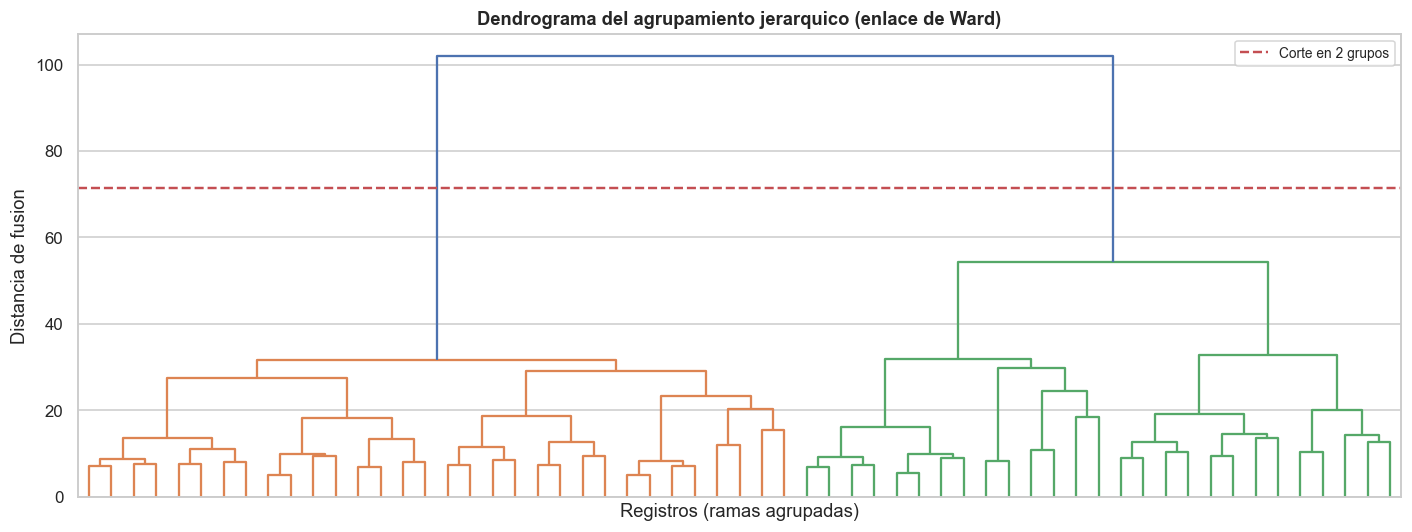

CONCORDANCIA ENTRE LOS DOS METODOS DE AGRUPAMIENTO
Jerarquico    0    1
K-Means             
0             9  366
1           175   19

Indice de Rand ajustado entre ambos : 0.8102
Silueta del jerarquico              : 0.3394
Silueta de K-Means                  : 0.3434

Un valor alto significa que los dos algoritmos, con logicas distintas y sin
coordinarse, encontraron practicamente la misma particion. Eso refuerza la
idea de que la estructura pertenece a los datos y no al metodo elegido.


In [38]:
# VISUALIZACION 12: dendrograma
enlaces = linkage(X_esc, method='ward')

plt.figure(figsize=(13, 5))
dendrogram(enlaces, truncate_mode='level', p=5, color_threshold=enlaces[-1, 2] * 0.7,
           no_labels=True)
plt.axhline(enlaces[-1, 2] * 0.7, color=ROJO, linestyle='--', linewidth=1.6,
            label='Corte en 2 grupos')
plt.title('Dendrograma del agrupamiento jerarquico (enlace de Ward)')
plt.xlabel('Registros (ramas agrupadas)')
plt.ylabel('Distancia de fusion')
plt.legend(fontsize=9)
plt.tight_layout(); plt.show()

jerarquico = AgglomerativeClustering(n_clusters=K_ELEGIDO, linkage='ward')
grupos_jer = jerarquico.fit_predict(X_esc)

acuerdo = adjusted_rand_score(grupos, grupos_jer)
print('CONCORDANCIA ENTRE LOS DOS METODOS DE AGRUPAMIENTO')
print('=' * 70)
print(pd.crosstab(pd.Series(grupos, name='K-Means'),
                  pd.Series(grupos_jer, name='Jerarquico')).to_string())
print()
print(f'Indice de Rand ajustado entre ambos : {acuerdo:.4f}')
print(f'Silueta del jerarquico              : {silhouette_score(X_esc, grupos_jer):.4f}')
print(f'Silueta de K-Means                  : {silhouette_score(X_esc, grupos):.4f}')
print()
print('Un valor alto significa que los dos algoritmos, con logicas distintas y sin')
print('coordinarse, encontraron practicamente la misma particion. Eso refuerza la')
print('idea de que la estructura pertenece a los datos y no al metodo elegido.')

#### 6.5.1 Dos algoritmos distintos, la misma partición

El **índice de Rand ajustado entre K-Means y el agrupamiento jerárquico es 0.8102**, y la tabla
cruzada muestra que sólo **28 de 569 registros** (el 4.9 %) cambian de grupo al cambiar de algoritmo.
Las siluetas son prácticamente iguales: 0.3434 contra 0.3394.

Esto es una verificación importante. K-Means y Ward parten de lógicas opuestas —uno coloca centroides
y los ajusta iterativamente, el otro fusiona registros de abajo hacia arriba minimizando el aumento
de varianza— y no comparten supuestos. Que lleguen casi al mismo resultado significa que **la
partición encontrada es una propiedad de los datos, no un artefacto del método**.

El dendrograma lo muestra visualmente: la fusión final, la que une los dos grandes bloques, ocurre a
una distancia mucho mayor que todas las anteriores. Ese salto es la firma de una separación real.


### 6.6 Respuesta a la pregunta no supervisada

> *Si se ocultan los diagnósticos, ¿los casos se separan en grupos naturales? ¿Cuántos, y qué los
> distingue?*

**Sí, y son dos.** Los tres criterios internos coinciden en k = 2, el codo se quiebra ahí, y un
segundo algoritmo con supuestos distintos encuentra esencialmente la misma partición (ARI = 0.8102).

Los grupos se distinguen por la **irregularidad del contorno nuclear** antes que por el tamaño: los
puntos cóncavos y la concavidad son las variables que más los separan (+1.72 y +1.70 desviaciones
estándar), por encima del área o el perímetro. Uno de los grupos es compacto y homogéneo (silueta
0.45, sin registros mal acomodados); el otro es difuso y heterogéneo (silueta 0.14, con 41 registros
en zona fronteriza).

Todo lo anterior se obtuvo **sin haber consultado un solo diagnóstico**.


---

# PARTE III — Confrontación de los dos enfoques

## 7. Qué respondió cada uno

Ahora, y sólo ahora, se recupera la variable objetivo para confrontarla con los grupos hallados. Es
importante entender **qué significa y qué no significa** esta comparación:

- **No es una evaluación del agrupamiento.** K-Means no intentaba predecir el diagnóstico, así que no
  puede «fallar» en algo que nunca se propuso. Las métricas internas de la sección 6 son las que
  evalúan su calidad.
- **Sí es una validación externa de la estructura.** Si los grupos coinciden con el diagnóstico,
  significa que la frontera clínica dejó una huella geométrica en los datos, detectable sin conocerla.


In [39]:
contingencia = pd.crosstab(pd.Series(grupos, name='Grupo K-Means'),
                           df['diagnostico'], margins=True, margins_name='Total')

print('TABLA DE CONTINGENCIA: GRUPOS DESCUBIERTOS vs. DIAGNOSTICO REAL')
print('=' * 70)
print(contingencia.to_string())
print()

# Cada grupo se asocia al diagnostico predominante en el (mapeo posterior)
mapa_grupo = {}
for g in range(K_ELEGIDO):
    mapa_grupo[g] = int(pd.Series(y.values[grupos == g]).mode()[0])
etiqueta_por_grupo = np.array([mapa_grupo[g] for g in grupos])

print('ASOCIACION DE CADA GRUPO CON SU DIAGNOSTICO PREDOMINANTE')
print('=' * 70)
for g, etq in mapa_grupo.items():
    m = grupos == g
    pureza = (y.values[m] == etq).mean()
    print(f'  Grupo {g} -> {"Maligno" if etq else "Benigno":8s} | '
          f'n = {m.sum():3d} | pureza = {pureza * 100:5.1f} %')

concordancia = accuracy_score(y, etiqueta_por_grupo)
ari = adjusted_rand_score(y, grupos)
nmi = normalized_mutual_info_score(y, grupos)

print()
print('METRICAS EXTERNAS (calculadas DESPUES del agrupamiento)')
print('=' * 70)
print(f'  Concordancia con el diagnostico : {concordancia:.4f}')
print(f'  Indice de Rand ajustado (ARI)   : {ari:.4f}')
print(f'  Informacion mutua normalizada   : {nmi:.4f}')
print()
print('El ARI vale 0 si la coincidencia es la esperable por azar y 1 si es')
print('perfecta. La NMI mide cuanta informacion sobre el diagnostico contiene la')
print('pertenencia a un grupo.')

TABLA DE CONTINGENCIA: GRUPOS DESCUBIERTOS vs. DIAGNOSTICO REAL
diagnostico    Benigno  Maligno  Total
Grupo K-Means                         
0                  339       36    375
1                   18      176    194
Total              357      212    569

ASOCIACION DE CADA GRUPO CON SU DIAGNOSTICO PREDOMINANTE
  Grupo 0 -> Benigno  | n = 375 | pureza =  90.4 %
  Grupo 1 -> Maligno  | n = 194 | pureza =  90.7 %

METRICAS EXTERNAS (calculadas DESPUES del agrupamiento)
  Concordancia con el diagnostico : 0.9051
  Indice de Rand ajustado (ARI)   : 0.6536
  Informacion mutua normalizada   : 0.5324

El ARI vale 0 si la coincidencia es la esperable por azar y 1 si es
perfecta. La NMI mide cuanta informacion sobre el diagnostico contiene la
pertenencia a un grupo.


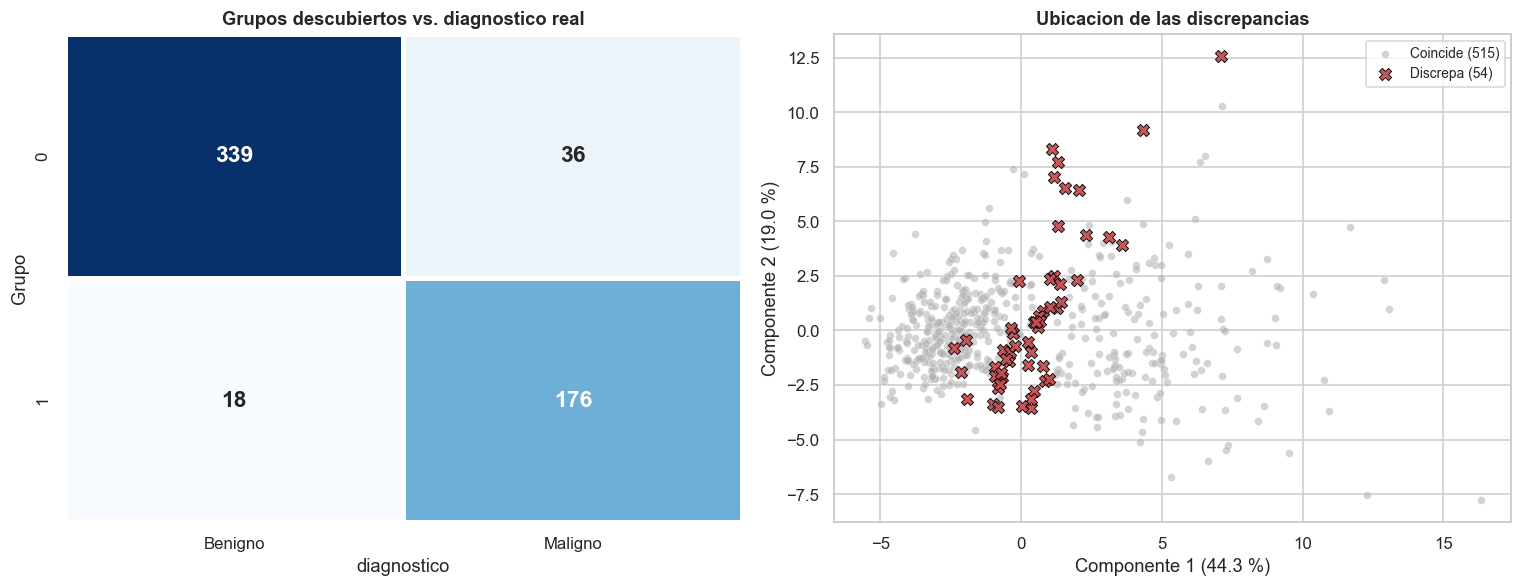

Silueta media de los casos que COINCIDEN : 0.3602
Silueta media de los casos que DISCREPAN : 0.1830

Las discrepancias no estan repartidas al azar: se concentran en la zona
donde ambos grupos se tocan, y tienen siluetas mas bajas. Son los mismos
casos ambiguos que la SVM resolvia con la ayuda de la etiqueta.


In [40]:
# VISUALIZACION 13: donde coincide y donde discrepa el agrupamiento
acierto = etiqueta_por_grupo == y.values

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sns.heatmap(pd.crosstab(pd.Series(grupos, name='Grupo'), df['diagnostico']),
            annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            annot_kws={'size': 15, 'weight': 'bold'}, linewidths=2, linecolor='white')
axes[0].set_title('Grupos descubiertos vs. diagnostico real')

axes[1].scatter(coords[acierto, 0], coords[acierto, 1], s=26, alpha=0.55,
                color='#B0B0B0', edgecolor='white', linewidth=0.3,
                label=f'Coincide ({acierto.sum()})')
axes[1].scatter(coords[~acierto, 0], coords[~acierto, 1], s=64, alpha=0.95,
                color=ROJO, edgecolor='black', linewidth=0.6, marker='X',
                label=f'Discrepa ({(~acierto).sum()})')
axes[1].set_xlabel(f'Componente 1 ({var_exp[0] * 100:.1f} %)')
axes[1].set_ylabel(f'Componente 2 ({var_exp[1] * 100:.1f} %)')
axes[1].set_title('Ubicacion de las discrepancias')
axes[1].legend(fontsize=9)

plt.tight_layout(); plt.show()

sil_ok = valores_sil[acierto].mean()
sil_no = valores_sil[~acierto].mean()
print(f'Silueta media de los casos que COINCIDEN : {sil_ok:.4f}')
print(f'Silueta media de los casos que DISCREPAN : {sil_no:.4f}')
print()
print('Las discrepancias no estan repartidas al azar: se concentran en la zona')
print('donde ambos grupos se tocan, y tienen siluetas mas bajas. Son los mismos')
print('casos ambiguos que la SVM resolvia con la ayuda de la etiqueta.')

### 7.1 La estructura geométrica reproduce la frontera clínica

Los números son contundentes:

| Métrica | Valor | Cómo se lee |
|---|---|---|
| Concordancia con el diagnóstico | **90.51 %** | 515 de 569 casos caen en el grupo que les corresponde |
| Pureza del grupo 0 | **90.4 %** | 339 benignos y 36 malignos |
| Pureza del grupo 1 | **90.7 %** | 176 malignos y 18 benignos |
| Índice de Rand ajustado | **0.6536** | Coincidencia muy por encima del azar (que daría 0) |
| Información mutua normalizada | **0.5324** | Saber el grupo aporta la mitad de la información del diagnóstico |

**Qué significa esto exactamente.** Un algoritmo que nunca vio un diagnóstico, que sólo midió
distancias entre 569 vectores de 30 números, reconstruyó el 90.5 % de una clasificación clínica
confirmada por biopsia. La conclusión no es que K-Means sirva para diagnosticar —no sirve, y la
sección 7.3 lo cuantifica— sino algo más profundo: **la distinción entre maligno y benigno está
inscrita en la geometría de las mediciones**. No fue introducida por el etiquetado; el etiquetado
sólo le puso nombre a una separación que ya existía en los datos.

**Dónde falla la coincidencia.** Los 54 casos discrepantes tienen una **silueta media de 0.1830**,
frente a **0.3602** de los que coinciden. No están repartidos al azar: se concentran en la franja
donde los dos grupos se tocan. Son precisamente los casos que la SVM resolvió *porque tenía la
etiqueta para hacerlo* — y ocupan la misma franja del espacio que los vectores de soporte de la sección 5.7.
Los dos enfoques identifican la misma zona de ambigüedad; sólo uno de ellos dispone de la información
necesaria para resolverla.


### 7.2 Por qué no debe esperarse que los clusters reproduzcan las etiquetas

El 9.5 % de casos donde grupo y diagnóstico no coinciden no es un fallo del algoritmo. Es la
consecuencia directa de que **K-Means y el diagnóstico responden a criterios distintos**, y conviene
tenerlo claro antes de interpretar cualquier discrepancia:

**1. K-Means agrupa por proximidad geométrica, no por causa clínica.** Su único criterio es la
distancia euclidiana en el espacio de 30 variables escaladas. Nunca se le informó qué significan esas
variables ni que existiera algo llamado «malignidad». Que el resultado se parezca al diagnóstico es
un hallazgo sobre los datos, no un objetivo cumplido.

**2. Sus supuestos geométricos no coinciden con la forma real de los datos.** K-Means busca grupos
**esféricos y de tamaño similar**. La proyección PCA de la sección 6.3 muestra nubes alargadas y
desiguales — 375 contra 194 registros. Donde la forma real se aparta de la esférica, la frontera del
algoritmo se desvía necesariamente de la clínica.

**3. La malignidad no es una propiedad puramente morfológica.** El diagnóstico se confirmó por
biopsia, integrando información histológica que **no está en estas 30 columnas**. Un tumor maligno en
etapa temprana puede tener núcleos de apariencia casi normal: es morfológicamente similar a un
benigno aunque clínicamente no lo sea. Esos casos caerán en el grupo «equivocado» sin que el
algoritmo haya hecho nada mal — los dos falsos negativos de la SVM (secc. 5.10) son exactamente de
ese tipo, con `mean concave points` de 0.058 y 0.051, valores propios de tejido benigno.

**4. La transición biológica es gradual, no discreta.** La etiqueta impone un corte binario sobre un
fenómeno continuo. La silueta de 0.3434 lo refleja: los grupos existen, pero se tocan. Los casos de
esa zona de contacto podrían asignarse a cualquiera de los dos lados sin violar la geometría.

**Cómo debe leerse entonces la correspondencia.** El 90.51 % de coincidencia no mide el acierto de
K-Means —que no intentaba acertar nada— sino **cuánta de la distinción clínica quedó impresa en la
morfología celular**. Es una afirmación sobre la calidad de las variables medidas, no sobre la
calidad del algoritmo.


In [41]:
# Comparacion sobre EXACTAMENTE los mismos 114 registros de prueba
pos_test = X.index.get_indexer(X_test.index)
cluster_en_prueba = etiqueta_por_grupo[pos_test]

tn_c, fp_c, fn_c, tp_c = confusion_matrix(y_test, cluster_en_prueba,
                                          labels=[0, 1]).ravel()

comparativa = pd.DataFrame([
    fila_base,
    fila_svm,
    {'Modelo'      : 'Grupos K-Means (asociados a posteriori)',
     'Exactitud'   : round(accuracy_score(y_test, cluster_en_prueba), 4),
     'Precision'   : round(precision_score(y_test, cluster_en_prueba, zero_division=0), 4),
     'Sensibilidad': round(recall_score(y_test, cluster_en_prueba, zero_division=0), 4),
     'Especificid.': round(tn_c / (tn_c + fp_c), 4),
     'F1'          : round(f1_score(y_test, cluster_en_prueba, zero_division=0), 4),
     'FN'          : int(fn_c), 'FP': int(fp_c)},
])

print('LOS TRES ENFOQUES SOBRE LOS MISMOS 114 REGISTROS DE PRUEBA')
print('=' * 70)
print(comparativa.to_string(index=False))
print()
print('ADVERTENCIA METODOLOGICA')
print('-' * 70)
print('Esta tabla NO es una competencia justa y no debe leerse como tal:')
print('  - La SVM se entreno con 455 diagnosticos y se evalua en 114 que no vio.')
print('  - K-Means nunca vio un solo diagnostico; la asociacion grupo-clase se')
print('    hizo despues, con el conjunto completo.')
print('El valor de la comparacion no esta en quien gana, sino en la MAGNITUD de la')
print('diferencia: cuanto aporta realmente disponer de las etiquetas.')

brecha_f1 = comparativa.iloc[1]['F1'] - comparativa.iloc[2]['F1']
print()
print(f'Brecha de F1 entre SVM supervisada y agrupamiento: {brecha_f1:+.4f}')

LOS TRES ENFOQUES SOBRE LOS MISMOS 114 REGISTROS DE PRUEBA
                                 Modelo  Exactitud  Precision  Sensibilidad  Especificid.     F1  FN  FP
           Linea base (siempre Benigno)     0.6316     0.0000        0.0000        1.0000 0.0000  42   0
                         SVM optimizada     0.9825     1.0000        0.9524        1.0000 0.9756   2   0
Grupos K-Means (asociados a posteriori)     0.8947     0.9167        0.7857        0.9583 0.8462   9   3

ADVERTENCIA METODOLOGICA
----------------------------------------------------------------------
Esta tabla NO es una competencia justa y no debe leerse como tal:
  - La SVM se entreno con 455 diagnosticos y se evalua en 114 que no vio.
  - K-Means nunca vio un solo diagnostico; la asociacion grupo-clase se
    hizo despues, con el conjunto completo.
El valor de la comparacion no esta en quien gana, sino en la MAGNITUD de la
diferencia: cuanto aporta realmente disponer de las etiquetas.

Brecha de F1 entre SVM super

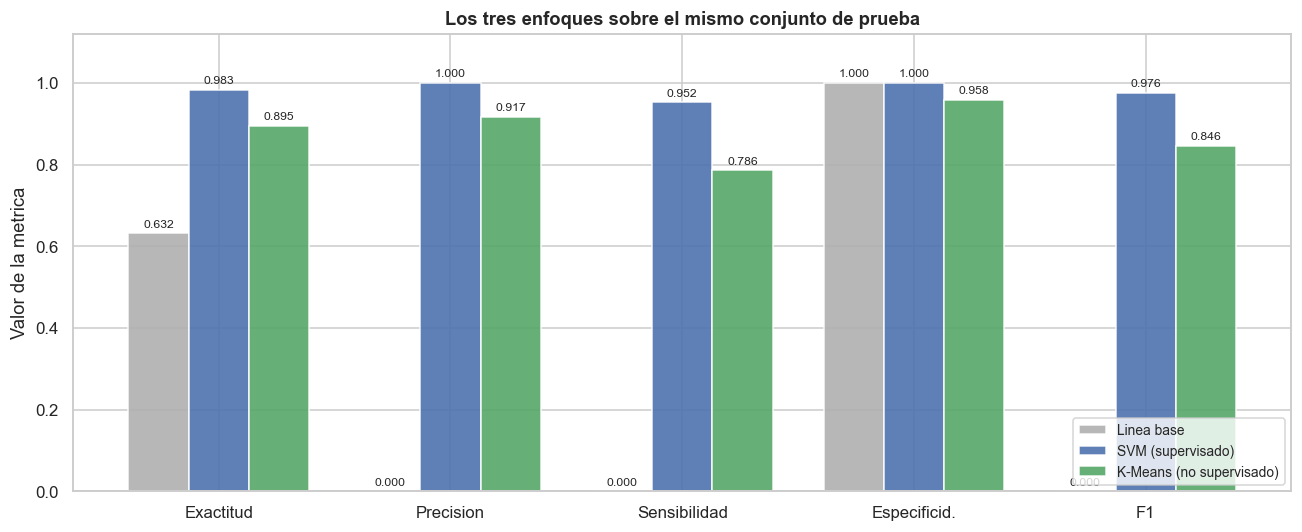

In [42]:
# VISUALIZACION 14: comparacion visual de metricas
metricas = ['Exactitud', 'Precision', 'Sensibilidad', 'Especificid.', 'F1']
etiquetas_modelo = ['Linea base', 'SVM (supervisado)', 'K-Means (no supervisado)']
valores = comparativa[metricas].values

x_pos = np.arange(len(metricas))
ancho = 0.26

fig, ax = plt.subplots(figsize=(12, 5))
for i, (nombre, color) in enumerate(zip(etiquetas_modelo, ['#B0B0B0', AZUL, VERDE])):
    barras = ax.bar(x_pos + (i - 1) * ancho, valores[i], ancho, label=nombre,
                    color=color, edgecolor='white', alpha=0.9)
    for b, v in zip(barras, valores[i]):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.015, f'{v:.3f}',
                ha='center', fontsize=8)

ax.set_xticks(x_pos); ax.set_xticklabels(metricas)
ax.set_ylim(0, 1.12); ax.set_ylabel('Valor de la metrica')
ax.set_title('Los tres enfoques sobre el mismo conjunto de prueba')
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout(); plt.show()

### 7.3 Cuánto valen realmente las etiquetas

La tabla anterior permite poner precio a la supervisión, que es la pregunta práctica de fondo:

| | SVM (supervisado) | K-Means (no supervisado) | Diferencia |
|---|---|---|---|
| Exactitud | 0.9825 | 0.8947 | +0.0878 |
| Sensibilidad | 0.9524 | 0.7857 | **+0.1667** |
| Precisión | 1.0000 | 0.9167 | +0.0833 |
| F1 | 0.9756 | 0.8462 | **+0.1294** |
| Falsos negativos | **2** | **9** | −7 |

**El agrupamiento llega sorprendentemente lejos por sí solo.** Un 89.5 % de exactitud sin haber visto
jamás un diagnóstico es un resultado notable, y confirma que el grueso de la señal está en la
morfología.

**Pero la diferencia se concentra donde más importa.** La brecha en exactitud es de 8.8 puntos; la
brecha en **sensibilidad es del doble: 16.7 puntos**. Traducido a casos: el agrupamiento deja pasar
**9 tumores malignos de 42**, mientras que la SVM deja pasar **2**. Esos siete casos son el valor
concreto de disponer de etiquetas.

**Y ese valor está localizado.** Las etiquetas no mejoran la clasificación de los casos claros —el
agrupamiento ya los resolvía— sino la de los casos fronterizos, la misma franja sobre la que se
sostienen los 56 vectores de soporte de la SVM. La supervisión no aporta información sobre todo el conjunto: aporta
información sobre su frontera.

> **Recordatorio metodológico.** Esta tabla compara dos cosas que no son comparables en sentido
> estricto, y no debe leerse como un torneo. K-Means no intentaba clasificar; se le está midiendo con
> una vara que no le corresponde. El propósito del ejercicio es cuantificar la brecha, no declarar un
> ganador.


### 7.4 Las dos preguntas, lado a lado

| | **SVM (supervisado)** | **K-Means (no supervisado)** |
|---|---|---|
| **Pregunta que responde** | ¿Esta masa es maligna o benigna? | ¿Existen grupos naturales en estos datos? |
| **Requiere etiquetas** | Sí, para entrenar | No, en ningún momento |
| **Qué produce** | Una regla de decisión aplicable a casos nuevos | Una partición del conjunto y el perfil de cada grupo |
| **Cómo se evalúa** | Métricas externas: F1, sensibilidad, AUC, matriz de confusión | Métricas internas: silueta, Davies-Bouldin, Calinski-Harabasz |
| **Qué es un «error»** | Predecir mal una clase conocida | El concepto no aplica: no hay respuesta correcta previa |
| **Riesgo principal** | Sobreajuste; y sin etiquetas de calidad no existe modelo | Grupos sin sentido interpretable, o un `k` mal elegido |
| **Requisito previo** | Un conjunto etiquetado, costoso de obtener en medicina | Sólo las mediciones |
| **Cuándo se usa** | Cuando ya existe el diagnóstico y se quiere automatizar | Cuando aún no se sabe qué estructura tienen los datos |

**El punto que hace valiosa la comparación.** Los dos enfoques no compiten: **se encadenan**. El
agrupamiento es lo que se puede hacer cuando aún no hay diagnósticos confirmados, y su resultado
—que existen dos grupos morfológicamente distintos— es precisamente la evidencia que justifica
invertir en etiquetar y entrenar un clasificador. La SVM, a su vez, sólo es posible porque alguien ya
pagó el costo de confirmar 569 diagnósticos por biopsia.


---

## 8. Conclusión

### 8.1 Qué información aportó la SVM

La SVM respondió una pregunta cerrada y la respondió bien: **de las 42 masas malignas del conjunto de
prueba, identifica 40**, con 98.25 % de exactitud, recall de 0.9524 y AUC de 0.9960, sin producir
ninguna falsa alarma. La validación cruzada confirma que el resultado no fue suerte de la partición
(F1 = 0.9669 ± 0.0157).

El recorrido de los tres modelos deja ver de dónde vino cada mejora:

| Modelo | F1 en prueba | Falsos negativos |
|---|---|---|
| Modelo 1 — kernel lineal | 0.9500 | 4 |
| Modelo 2 — kernel RBF por omisión | 0.9630 | 3 |
| RBF optimizado (`C = 10`, `gamma = 0.01`) | **0.9756** | **2** |

Pero lo que la SVM aportó va más allá del porcentaje. Aportó **una regla de decisión aplicable a un
caso nuevo**, algo que ningún análisis descriptivo puede dar. Aportó también **una medida del costo
de equivocarse**: la tabla de umbrales de la sección 5.6 muestra que bajar el corte a −0.50 recupera
uno de los dos casos perdidos a cambio de una sola falsa alarma, y esa es una decisión que un comité
clínico puede tomar con números en la mano. Y aportó **una localización del problema**: el modelo se
sostiene sobre 56 registros de 455, todos en la franja ambigua entre ambas clases.

### 8.2 Qué patrones permitió descubrir K-Means

K-Means no predijo nada; **describió**. Y descubrió tres cosas que el análisis supervisado no podía
revelar, porque este último parte de saber la respuesta:

1. **Existen exactamente dos grupos naturales.** Los tres criterios internos —silueta, Davies-Bouldin
   y Calinski-Harabasz— coinciden en k = 2, el codo se quiebra ahí (32.1 % de la inercia eliminada
   contra 13.2 % del siguiente corte) y un algoritmo jerárquico independiente reproduce la misma
   partición (ARI = 0.8102). Ese número **no se le dio: lo encontró**.
2. **Los dos grupos se distinguen por la forma del contorno, no por el tamaño.** Los puntos cóncavos
   y la concavidad son las variables que más los separan (+1.72 y +1.70 desviaciones estándar), por
   encima del área o del perímetro.
3. **Los dos grupos no tienen la misma naturaleza interna.** Uno es compacto y homogéneo (silueta
   0.45, ningún registro mal acomodado); el otro es difuso (silueta 0.14, con 41 casos fronterizos).
   Traducido: **el tejido benigno se parece a sí mismo, mientras que la anomalía admite muchas
   formas**. Ninguna métrica del análisis supervisado habría mostrado esa asimetría.

Y al confrontar los grupos con el diagnóstico —una vez cerrado el agrupamiento— apareció el hallazgo
que ninguno de los dos enfoques daba por separado: **coinciden en el 90.51 % de los casos**
(ARI = 0.6536). La frontera clínica ya estaba inscrita en la geometría de las mediciones.

### 8.3 Qué enfoque fue más fácil de interpretar

**El supervisado, y por una razón estructural, no por casualidad.** La SVM se evalúa contra una
respuesta correcta que existe con independencia del modelo: cada número —recall de 0.9524, dos falsos
negativos— tiene un significado que no admite discusión. La matriz de confusión se lee sin
ambigüedad: esta casilla son cánceres no detectados, aquélla son falsas alarmas.

El agrupamiento exige un trabajo de interpretación que el modelo no hace por sí solo. K-Means entrega
«grupo 0» y «grupo 1»; que uno de ellos signifique algo es una conclusión del analista, obtenida
comparando perfiles de variables. Sus métricas tampoco se leen solas: una silueta de 0.3434 no dice
si el resultado es bueno o malo hasta situarla en una escala convencional y contrastarla con un
segundo algoritmo.

**Matiz importante:** más fácil de interpretar no significa más informativo. El agrupamiento respondió
una pregunta que la SVM ni siquiera puede plantearse —¿cuántos grupos hay?— y lo hizo sin necesitar
un solo diagnóstico confirmado.

### 8.4 Qué limitaciones se identificaron

- **Del enfoque supervisado.** Depende por completo de disponer de etiquetas confiables, que aquí
  costaron 569 biopsias. El conjunto de prueba es pequeño (114 registros), así que cada error mueve
  la exactitud casi un punto porcentual, y la precisión perfecta de 1.0000 es frágil. La SVM además
  no ofrece coeficientes interpretables como una regresión: dice *qué* clasificar, no *por qué*.
- **Del enfoque no supervisado.** K-Means exige fijar `k` de antemano y supone grupos esféricos y de
  tamaño similar, cosa que estos datos no cumplen (375 contra 194 registros, nubes alargadas). La
  redundancia entre variables lo sesga: radio, perímetro y área correlacionan por encima de 0.98 y
  pesan tres veces en la distancia euclidiana. Y la silueta de 0.34 indica una estructura real pero
  **débil**: los grupos se tocan.
- **Comunes a ambos.** Los datos son de una sola institución y de la década de 1990, y las 30
  variables ya provienen de una extracción de características diseñada por expertos, lo que facilita
  la tarea más de lo que sería realista. La sección 9 desarrolla estas reservas.

### 8.5 En qué tipo de problema se usaría cada técnica

| | **SVM — aprendizaje supervisado** | **K-Means — aprendizaje no supervisado** |
|---|---|---|
| **Se usa cuando** | Existe un histórico etiquetado y se quiere **predecir la etiqueta** de casos nuevos | No hay etiquetas, o se quiere **explorar** qué estructura tienen los datos |
| **La pregunta típica** | ¿A qué clase pertenece este caso? | ¿Hay grupos aquí? ¿Cuántos? ¿En qué se diferencian? |
| **Ejemplos** | Diagnóstico asistido, detección de fraude, filtrado de correo, control de calidad | Segmentación de clientes, detección de anomalías, agrupación de documentos, exploración inicial |
| **Qué se obtiene** | Una regla de decisión y métricas de confianza | Una partición, un perfil por grupo y una hipótesis a verificar |
| **Requisito crítico** | Etiquetas de calidad; sin ellas no hay modelo posible | Variables comparables entre sí (escalado) y un criterio para elegir `k` |
| **Riesgo principal** | Sobreajuste; el modelo hereda cualquier sesgo del etiquetado | Grupos sin sentido interpretable, o un `k` mal elegido |

### 8.6 La diferencia de fondo

**Predecir una clase conocida y explorar una estructura desconocida no son dos versiones de la misma
tarea.** El aprendizaje supervisado parte de una respuesta que alguien ya estableció y aprende a
reproducirla; su éxito se mide comparando contra esa respuesta, y su techo es la calidad del
etiquetado. El aprendizaje no supervisado no tiene respuesta contra la cual compararse: **construye
la pregunta al mismo tiempo que la responde**, y su validación depende de criterios internos y de la
plausibilidad de lo que encuentra.

Por eso no compiten: **se encadenan**. El agrupamiento es lo que se puede hacer cuando aún no hay
diagnósticos, y su resultado —que existen dos grupos morfológicamente bien diferenciados— es
justamente la evidencia que justifica invertir en confirmarlos por biopsia y entrenar un
clasificador. La SVM, a su vez, sólo fue posible porque alguien ya pagó el costo de confirmar 569
diagnósticos.

Y la brecha entre ambos pone precio a ese costo: **F1 de 0.9756 contra 0.8462, y recall de 0.9524
contra 0.7857**. Siete tumores malignos más detectados de 42. Las etiquetas no valen por lo que dicen
del conjunto entero —el agrupamiento ya resolvía los casos claros— sino por lo que permiten decidir
**en la frontera**.


---

## 9. Limitaciones del análisis

Cuatro reservas que conviene declarar explícitamente:

**1. La redundancia entre variables sesga el agrupamiento.** Radio, perímetro y área tienen
correlaciones cercanas a 0.99 y las tres entran con el mismo peso en la distancia euclidiana. El
tamaño del núcleo termina contando por tres, mientras que características menos correlacionadas —
textura, simetría, dimensión fractal — pesan proporcionalmente menos. Una alternativa sería agrupar
sobre las componentes principales en lugar de sobre las variables originales.

**2. K-Means impone supuestos que los datos no necesariamente cumplen.** Busca grupos esféricos y de
tamaño parecido. La proyección PCA muestra nubes alargadas y de tamaños desiguales, lo cual explica
parte de las discrepancias en la frontera. Métodos como DBSCAN o mezclas gaussianas no requieren esa
geometría.

**3. El conjunto de prueba es pequeño.** Con 114 registros, cada error individual mueve la exactitud
casi un punto porcentual. Por eso la validación cruzada de la sección 5.8 es una referencia más
confiable que el número de la partición única.

**4. Estos datos no son representativos de la práctica clínica actual.** Fueron recolectados en la
década de 1990 en una sola institución, con una técnica de digitalización específica. Las variables
provienen ya de un proceso de extracción de características diseñado por expertos, lo que facilita
enormemente la tarea. Ningún resultado aquí obtenido autoriza a usar este modelo como herramienta
diagnóstica real.

---

## 10. Referencias

- scikit-learn developers. (s.f.). *load_breast_cancer*. Recuperado el 5 de septiembre de 2026 de
  https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html
- Wolberg, W. H., Street, W. N. y Mangasarian, O. L. (1995). *Breast Cancer Wisconsin (Diagnostic)*
  [Conjunto de datos]. UCI Machine Learning Repository. https://doi.org/10.24432/C5DW2B
- Street, W. N., Wolberg, W. H. y Mangasarian, O. L. (1993). Nuclear feature extraction for breast
  tumor diagnosis. *IS&T/SPIE International Symposium on Electronic Imaging: Science and Technology*,
  1905, 861–870.
- Cortes, C. y Vapnik, V. (1995). Support-vector networks. *Machine Learning*, 20(3), 273–297.
- Rousseeuw, P. J. (1987). Silhouettes: A graphical aid to the interpretation and validation of
  cluster analysis. *Journal of Computational and Applied Mathematics*, 20, 53–65.
- Pedregosa, F. et al. (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning
  Research*, 12, 2825–2830.
